# Parameter Derivation

### Stress Profiling
This corresponds to the first part of the parameter derivation procedure. We have used a video decoder with each frame being looped 5 times in the decorder (--work=5).
The workload has been run 100.000 times without any stress on the shared components, then with stress on the cache and then on the memory. Finally, an exeution wihtout any stress after the previous tests. These has been executed for single and multi-core.

#### Metrics
- **Execution time** = `end_ns - start_ns` (wall time of the job, upper bound on its CPU time)
- **Dispatch latency** = `start_ns - release_ns`

All executed jobs are included, outliers too. Skipped activations have no start/end timestamps, so there is nothing to measure for them.

In [158]:
from pathlib import Path
import pandas as pd
from scipy.stats import genextreme, kstest
import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path("../results")
SCENARIOS = {"single_core": ["instance0"], "multi_core": ["instance0", "instance1"]}
CONDITIONS = ["baseline1", "cache", "memory", "baseline2"]
STRESS = ["cache", "memory"]
# statistics shown per metric (quantile levels; 1.0 = max)
METRICS = {
    "cpu_ns":     ("CPU time (ns)",   {"p50": .50, "p99": .99, "p99.9": .999, "max": 1.0}),
    "exec_ms":     ("Execution time (ms)",   {"p50": .50, "p99": .99, "p99.9": .999, "max": 1.0}),
    "dispatch_us": ("Dispatch latency (µs)", {"p50": .50, "max": 1.0}),
}

frames = []
for scenario, instances in SCENARIOS.items():
    for condition in CONDITIONS:
        for inst in instances:
            df = pd.read_csv(RESULTS / scenario / condition / f"{inst}.csv")
            df["scenario"], df["condition"] = scenario, condition
            frames.append(df)
data = pd.concat(frames, ignore_index=True)

print("skipped activations (no timestamps):")
print(data.groupby(["scenario", "condition"], sort=False).skipped.sum().to_string())

data = data[data.skipped == 0].copy()
data["exec_ms"] = (data.end_ns - data.start_ns) / 1e6
data["dispatch_us"] = (data.start_ns - data.release_ns) / 1e3

skipped activations (no timestamps):
scenario     condition
single_core  baseline1      0
             cache         56
             memory         0
             baseline2      0
multi_core   baseline1    142
             cache          0
             memory         0
             baseline2      2


In [159]:
def stats_table(scenario):
    d = data[data.scenario == scenario]
    tbl = pd.concat(
        {name: d.groupby("condition")[m].quantile(list(stats.values())).unstack()
                .set_axis(list(stats), axis=1)
         for m, (name, stats) in METRICS.items()}, axis=1)
    # spread: how far the worst job is from the typical one
    for name, _ in METRICS.values():
        tbl[(name, "max vs p50 %")] = (tbl[(name, "max")] / tbl[(name, "p50")] - 1) * 100
    order = [c for name, _ in METRICS.values() for c in tbl.columns if c[0] == name]
    return tbl.loc[CONDITIONS, order]

def pct_table(tbl):
    tbl = tbl.drop(columns=[c for c in tbl.columns if c[1] == "max vs p50 %"])
    rows = {}
    for ref, name in [("baseline1", "before"), ("baseline2", "after")]:
        for s in STRESS:
            rows[f"{s} vs baseline {name}"] = (tbl.loc[s] / tbl.loc[ref] - 1) * 100
    return pd.DataFrame(rows).T

tables, pcts = {}, {}
for scenario in SCENARIOS:
    tables[scenario] = stats_table(scenario)
    pcts[scenario] = pct_table(tables[scenario])

### Single-core

In [160]:
display(tables["single_core"].style.format("{:,.2f}"))
display(pcts["single_core"].style.format("{:,.2f}%"))

### Multi-core (instance0 and instance1 pooled)

In [161]:
display(tables["multi_core"].style.format("{:,.2f}"))
display(pcts["multi_core"].style.format("{:,.2f}%"))

### How often are large dispatch latencies (W)?
W = `start_ns - release_ns`. Computed per instance, because the miss rate is defined per task.
If jobs with a large W are only a handful per 100,000, they form a rare floor of misses. If they are more frequent, they could dominate the miss rate at the tolerance levels 10⁻² and 10⁻³.
The `share of 1e-x` columns give the W > 5 ms rate as a fraction of each tolerance (e.g. 0.024 = 2.4% of the allowed misses).

In [162]:
THRESHOLDS_MS = [5, 15]
TOLERANCES = [1e-2, 1e-3]

def w_tail(g):
    w = g.dispatch_us
    row = {"jobs": len(w), "W p99 (µs)": w.quantile(.99), "W p99.9 (µs)": w.quantile(.999)}
    for t in THRESHOLDS_MS:
        row[f"W > {t} ms"] = int((w > t * 1_000).sum())
    for t in THRESHOLDS_MS:
        row[f"rate W > {t} ms"] = row[f"W > {t} ms"] / len(w)
    for tol in TOLERANCES:
        row[f"share of {tol:.0e}"] = row[f"rate W > {THRESHOLDS_MS[0]} ms"] / tol
    return pd.Series(row)

w_tbl = (data.groupby(["scenario", "instance_id", "condition"], sort=False)[["dispatch_us"]]
             .apply(w_tail).astype({f"W > {t} ms": int for t in THRESHOLDS_MS} | {"jobs": int}))
w_tbl.style.format({"W p99 (µs)": "{:,.1f}", "W p99.9 (µs)": "{:,.1f}",
                    **{f"rate W > {t} ms": "{:.1e}" for t in THRESHOLDS_MS},
                    **{f"share of {tol:.0e}": "{:.3f}" for tol in TOLERANCES}})

## Tail Estimation
We perform first Block Maxima and then Generalized Extreme Value Distirbution.

In [163]:
RESULTS = Path("../results")
SCENARIOS = {"single_core": ["instance0"], "multi_core": ["instance0", "instance1"]}
CONDITIONS = ["baseline1", "cache", "memory", "baseline2"]
STRESS = ["cache", "memory"]

frames = []
for scenario, instances in SCENARIOS.items():
    for condition in CONDITIONS:
        for inst in instances:
            df = pd.read_csv(RESULTS / scenario / condition / f"{inst}.csv")
            df["scenario"], df["condition"] = scenario, condition
            frames.append(df)
data = pd.concat(frames, ignore_index=True)

print("skipped activations (no timestamps):")
print(data.groupby(["scenario", "condition"], sort=False).skipped.sum().to_string())

data = data[data.skipped == 0].copy()
data["exec_ms"] = data.cpu_ns / 1e6

skipped activations (no timestamps):
scenario     condition
single_core  baseline1      0
             cache         56
             memory         0
             baseline2      0
multi_core   baseline1    142
             cache          0
             memory         0
             baseline2      2


In [164]:
def block_maxima(df, block_size=600, value_col="exec_ms"):
    # drop warmup and skipped jobs
    df = df[(~df["warmup"].astype(bool)) & (~df["skipped"].astype(bool))]
    out = []
    keys = ["scenario", "condition", "instance_id"]
    for (scen, cond, inst), g in df.groupby(keys, sort=False):
        # keep only instances belonging to this scenario
        if inst not in SCENARIOS.get(scen, []) or cond not in CONDITIONS:
            continue
        g = g.sort_values("job_id").reset_index(drop=True) 
        g["block"] = g.index // block_size
        # drop incomplete last block
        g = g[g["block"].map(g["block"].value_counts()) == block_size]
        m = g.groupby("block")[value_col].max().reset_index()
        m.insert(0, "instance_id", inst)
        m.insert(0, "condition", cond)
        m.insert(0, "scenario", scen)
        out.append(m)
    return pd.concat(out, ignore_index=True)

In [165]:
bm = block_maxima(data)
print(bm.groupby(["scenario", "condition", "instance_id"]).size())

scenario     condition  instance_id
multi_core   baseline1  instance0      166
                        instance1      166
             baseline2  instance0      166
                        instance1      166
             cache      instance0      166
                        instance1      166
             memory     instance0      166
                        instance1      166
single_core  baseline1  instance0      166
             baseline2  instance0      166
             cache      instance0      166
             memory     instance0      166
dtype: int64


In [166]:
# GEV fit per scenario x condition
rows = []
for (scen, cond), g in bm.groupby(["scenario", "condition"]):
    x = g["exec_ms"].to_numpy()  # instances pooled; filter by instance_id to split
    c, loc, scale = genextreme.fit(x)
    rows.append(dict(scenario=scen, condition=cond, n_blocks=len(x),
                    c=c, xi=-c, loc=loc, scale=scale,
                    rl_100=genextreme.isf(1 / 100, c, loc, scale)))
fits = pd.DataFrame(rows) 
print(fits) 

      scenario  condition  n_blocks         c        xi        loc     scale  \
0   multi_core  baseline1       332 -0.081454  0.081454  22.304523  0.165032   
1   multi_core  baseline2       332 -0.054002  0.054002  21.767879  0.180147   
2   multi_core      cache       332 -0.035229  0.035229  22.461252  0.225958   
3   multi_core     memory       332  0.131787 -0.131787  22.148448  0.186892   
4  single_core  baseline1       166 -0.009802  0.009802  22.570427  0.254519   
5  single_core  baseline2       166  0.128763 -0.128763  22.820686  0.164123   
6  single_core      cache       166 -0.105386  0.105386  22.997142  0.190599   
7  single_core     memory       166 -0.117715  0.117715  23.218015  0.282921   

      rl_100  
0  23.225491  
1  22.708592  
2  23.589660  
3  22.793135  
4  23.768051  
5  23.390390  
6  24.125401  
7  24.945112  


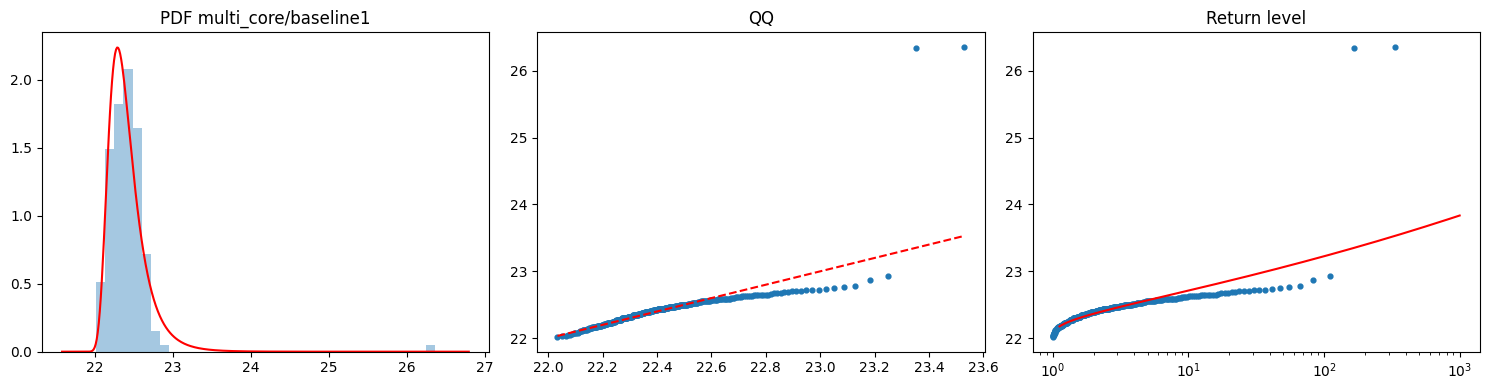

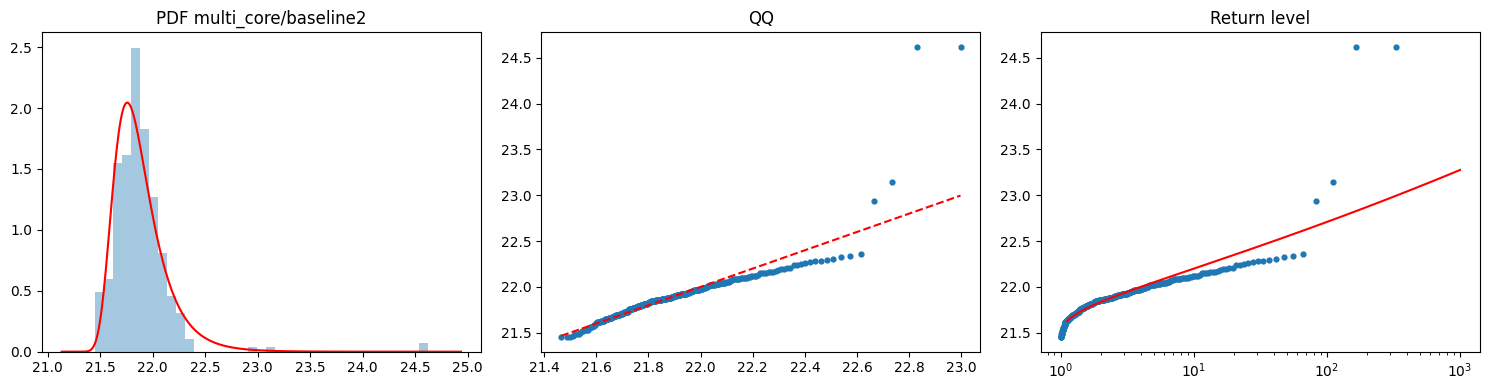

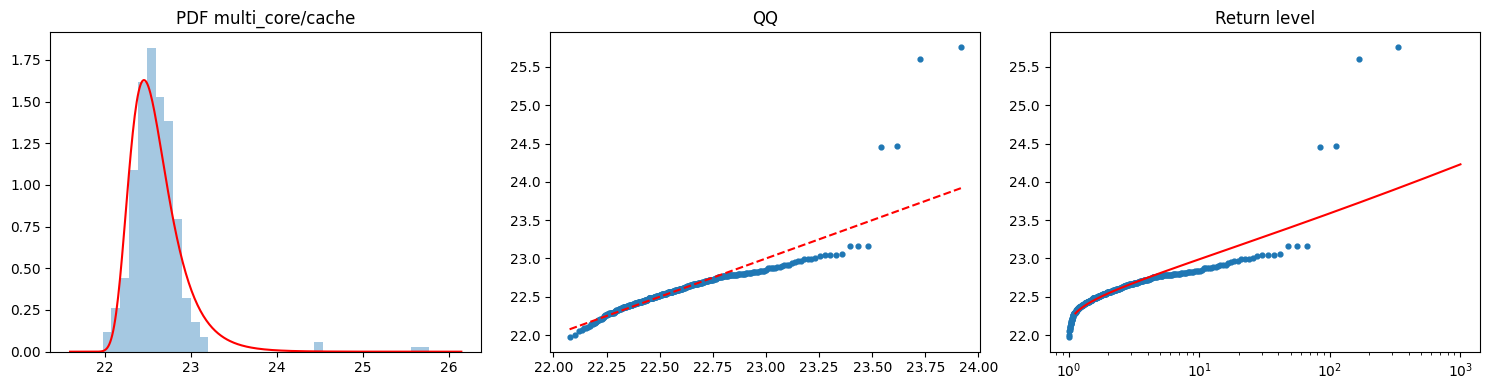

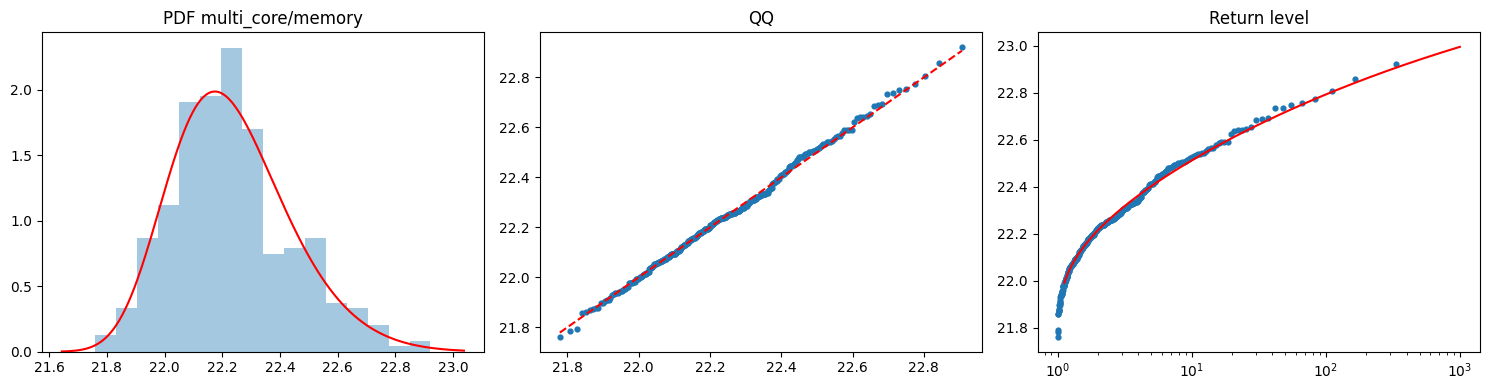

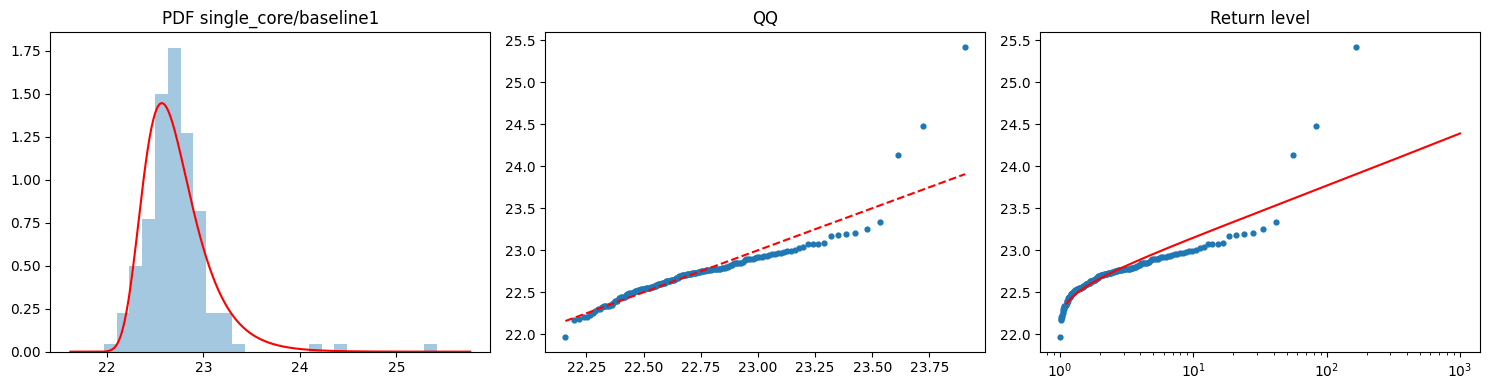

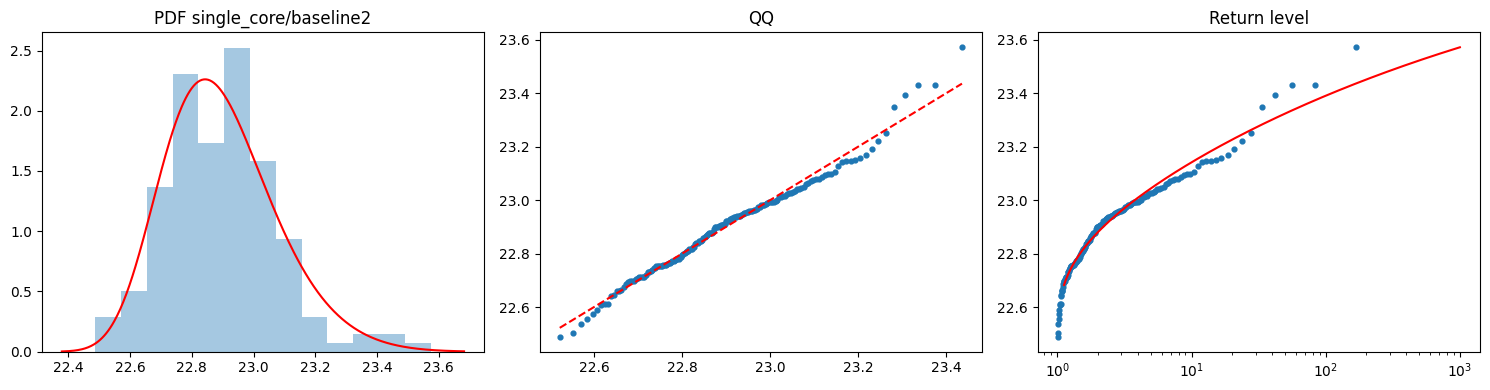

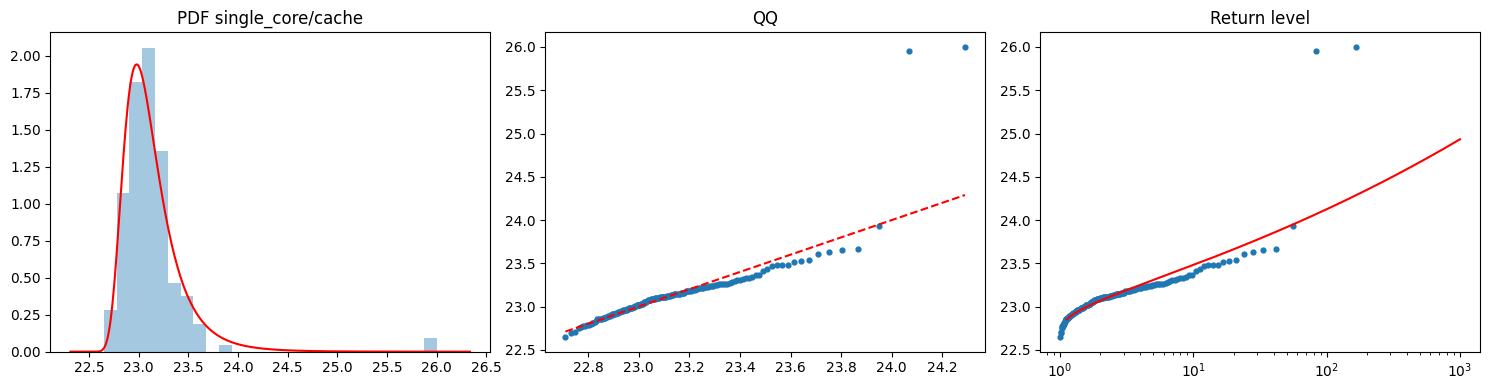

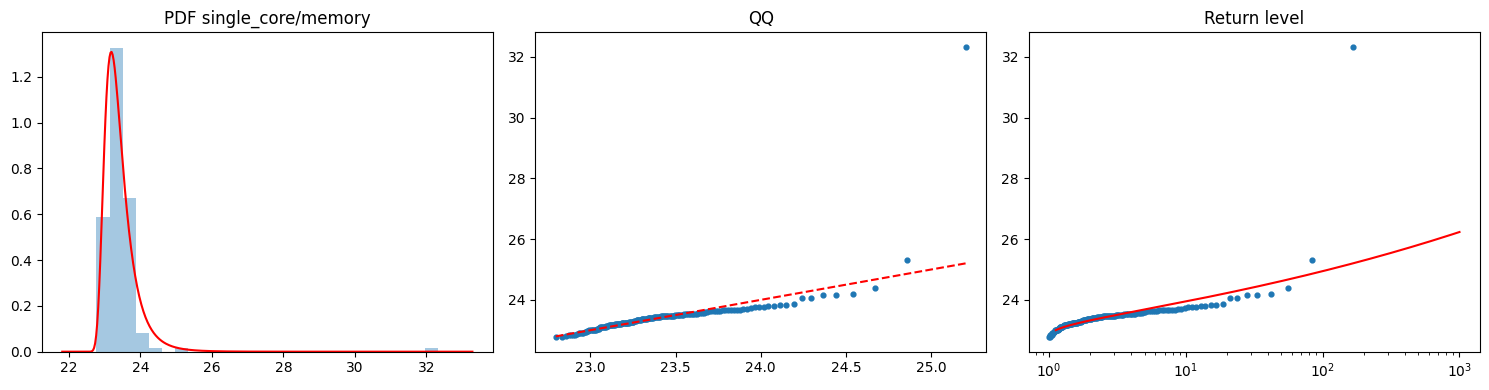

In [167]:
def plot_gev(x, title):
    c, loc, scale = genextreme.fit(x)
    xs = np.sort(x) 
    p = np.arange(1, len(xs) + 1) / (len(xs) + 1)
    grid = np.linspace(xs.min() - 0.1 * np.ptp(xs), xs.max() + 0.1 * np.ptp(xs), 400)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].hist(x, bins="auto", density=True, alpha=0.4)
    ax[0].plot(grid, genextreme.pdf(grid, c, loc, scale), "r-")
    ax[0].set_title(f"PDF {title}")
    q = genextreme.ppf(p, c, loc, scale)
    ax[1].scatter(q, xs, s=12)
    ax[1].plot([q.min(), q.max()], [q.min(), q.max()], "r--")
    ax[1].set_title("QQ")
    T = np.logspace(0.05, 3, 200)
    ax[2].semilogx(T, genextreme.isf(1 / T, c, loc, scale), "r-")
    ax[2].scatter(1 / (1 - p), xs, s=12)
    ax[2].set_title("Return level")
    plt.tight_layout()
    plt.show()
    
for (scen, cond), g in bm.groupby(["scenario", "condition"]):
    plot_gev(g["exec_ms"].to_numpy(), f"{scen}/{cond}")

Runs without isolated extremes showed a bounded tail (ξ ≈ −0.13) with an almost perfect fit, while positive shape parameters arose only from a few isolated block maxima. In multi-core these occurred simultaneously on both instances, indicating VM-level events rather than task behaviour; execution times are therefore a mixture of a short-tailed task component and rare platform events.

##### Check: platform event
By looking at the plots for multicore, we can notice many outliers. In order to classify them, we have to check whether they are happening on both side, on both cores.

In [168]:
Q = 0.9999
TOL_NS = 0 
N_SHIFT = 1000      # null replicates

rng = np.random.default_rng(0)


def overlaps(sa, ea, sb, eb, tol=TOL_NS):
    """count extremes in A that overlap >=1 extreme in B (intervals, +-tol)"""
    if len(sa) == 0 or len(sb) == 0:
        return np.zeros(len(sa), dtype=bool)
    hit = (sa[:, None] <= eb[None, :] + tol) & (ea[:, None] >= sb[None, :] - tol)
    return hit.any(axis=1)

def platform_events(df, scenario="multi_core", q=Q, tol=TOL_NS):
    d = df[(df["scenario"] == scenario) & (~df["warmup"].astype(bool))
            & (~df["skipped"].astype(bool))]
    rows = []
    for cond, g in d.groupby("condition", sort=False):
        a = g[g["instance_id"] == "instance0"]
        b = g[g["instance_id"] == "instance1"]
        thr_a, thr_b = a["exec_ms"].quantile(q), b["exec_ms"].quantile(q)
        xa, xb = a[a["exec_ms"] > thr_a], b[b["exec_ms"] > thr_b]
        sa, ea = xa["start_ns"].to_numpy(), xa["end_ns"].to_numpy()
        sb, eb = xb["start_ns"].to_numpy(), xb["end_ns"].to_numpy()
        
        n_coinc = int(overlaps(sa, ea, sb, eb, tol).sum())   # A extremes with B partner
        
        # run duration and rate
        t0 = g["start_ns"].min()
        t1 = g["end_ns"].max()
        span = t1 - t0
        hours = span / 1e9 / 3600
        
        # null: shift B's extremes by random offsets (wrap inside run), recount
        null = np.empty(N_SHIFT)
        for i in range(N_SHIFT):
            off = rng.integers(0, span)
            sb_s = (sb - t0 + off) % span + t0
            null[i] = overlaps(sa, ea, sb_s, sb_s + (eb - sb), tol).sum()
        p = (1 + np.sum(null >= n_coinc)) / (1 + N_SHIFT)
        
        rows.append(dict(
            condition=cond, n_jobs0=len(a), n_jobs1=len(b),
            thr0_ms=thr_a, thr1_ms=thr_b,
            n_ext0=len(xa), n_ext1=len(xb),
            n_coincident=n_coinc,
            frac_ext0_coincident=n_coinc / max(len(xa), 1),
            expected_by_chance=null.mean(), p_value=p,
            run_hours=hours,
            rate_per_hour=n_coinc / hours,
            rate_per_job=n_coinc / max(len(a), 1),
        ))  
    return pd.DataFrame(rows)

pe = platform_events(data)
print(pe.round(4).to_string(index=False))
pe.to_csv("platform_events.csv", index=False)

condition  n_jobs0  n_jobs1  thr0_ms  thr1_ms  n_ext0  n_ext1  n_coincident  frac_ext0_coincident  expected_by_chance  p_value  run_hours  rate_per_hour  rate_per_job
baseline1    99929    99929  22.7069  22.6000      10      10             4                   0.4               0.000    0.001     1.1574          3.456        0.0000
    cache   100000   100000  23.0390  22.9452      10      10             7                   0.7               0.000    0.001     1.1574          6.048        0.0001
   memory   100000   100000  22.6230  22.5134      10      10             5                   0.5               0.001    0.001     1.1574          4.320        0.0000
baseline2    99999    99999  22.2433  22.1698      10      10             6                   0.6               0.002    0.001     1.1574          5.184        0.0001


In [169]:
# how much latency is the platform adding?
def platform_floor(df, scenario="multi_core", q=Q, tol=TOL_NS):
    d = df[(df["scenario"] == scenario) & (~df["warmup"].astype(bool))
            & (~df["skipped"].astype(bool))]
    out = [] 
    for cond, g in d.groupby("condition", sort=False):
        a = g[g["instance_id"] == "instance0"]
        b = g[g["instance_id"] == "instance1"]
        xa = a[a["exec_ms"] > a["exec_ms"].quantile(q)]
        xb = b[b["exec_ms"] > b["exec_ms"].quantile(q)]
        m = overlaps(xa["start_ns"].to_numpy(), xa["end_ns"].to_numpy(),
                    xb["start_ns"].to_numpy(), xb["end_ns"].to_numpy(), tol)
        co = xa[m]   
        out.append(dict(
            condition=cond,
            median_ms=a["exec_ms"].median(),
            p99_ms=a["exec_ms"].quantile(0.99),
            coincident_min_ms=co["exec_ms"].min(),
            coincident_median_ms=co["exec_ms"].median(),
            coincident_max_ms=co["exec_ms"].max(),
            added_ms=co["exec_ms"].median() - a["exec_ms"].median(),
            ratio_to_median=co["exec_ms"].median() / a["exec_ms"].median(),
        ))  
    return pd.DataFrame(out)
    
print(platform_floor(data).round(3).to_string(index=False))

condition  median_ms  p99_ms  coincident_min_ms  coincident_median_ms  coincident_max_ms  added_ms  ratio_to_median
baseline1     14.961  22.086             22.720                22.852             26.341     7.891            1.527
    cache     15.117  22.239             23.042                23.614             25.597     8.498            1.562
   memory     14.757  21.874             22.655                22.807             22.922     8.051            1.546
baseline2     14.359  21.459             22.253                22.352             24.613     7.993            1.557


In [170]:
Q_RES = 0.9999        # quantile of residuals; or use ABS_MS instead
ABS_MS = None         # e.g. 1.0 -> extreme if residual > 1 ms (overrides Q_RES)
TOL_NS = 0
N_SHIFT = 1000
VALUE = "exec_ms"     # or add a cpu_ms column = cpu_ns/1e6 and use that


def add_residuals(df, value=VALUE):
    d = df[(~df["warmup"].astype(bool)) & (~df["skipped"].astype(bool))].copy()
    # typical time of each frame: median over all passes, per run and instance
    keys = ["scenario", "condition", "instance_id", "frame_idx"]
    d["frame_typ"] = d.groupby(keys)[value].transform("median")
    d["resid_ms"] = d[value] - d["frame_typ"]
    return d


def platform_events_resid(df, scenario="multi_core", q=Q_RES, abs_ms=ABS_MS, tol=TOL_NS):
    d = add_residuals(df)
    d = d[d["scenario"] == scenario]
    rows = [] 
    for cond, g in d.groupby("condition", sort=False):
        a = g[g["instance_id"] == "instance0"] 
        b = g[g["instance_id"] == "instance1"] 
        ta = abs_ms if abs_ms is not None else a["resid_ms"].quantile(q)
        tb = abs_ms if abs_ms is not None else b["resid_ms"].quantile(q)
        xa, xb = a[a["resid_ms"] > ta], b[b["resid_ms"] > tb]
        sa, ea = xa["start_ns"].to_numpy(), xa["end_ns"].to_numpy()
        sb, eb = xb["start_ns"].to_numpy(), xb["end_ns"].to_numpy()
        m = overlaps(sa, ea, sb, eb, tol)
        n_coinc = int(m.sum())
        
        t0, t1 = g["start_ns"].min(), g["end_ns"].max()
        span = t1 - t0
        hours = span / 1e9 / 3600
        
        # null: shift B's extremes in time. Valid now because content is removed.
        null = np.empty(N_SHIFT)
        for i in range(N_SHIFT):
            off = rng.integers(0, span)
            sb_s = (sb - t0 + off) % span + t0
            null[i] = overlaps(sa, ea, sb_s, sb_s + (eb - sb), tol).sum()
        p = (1 + np.sum(null >= n_coinc)) / (1 + N_SHIFT)
        
        co = xa[m]
        rows.append(dict(
            condition=cond, thr_resid_ms=ta,
            n_ext0=len(xa), n_ext1=len(xb), n_coincident=n_coinc,
            frac_ext0_coincident=n_coinc / max(len(xa), 1),
            expected_by_chance=null.mean(), p_value=p,
            rate_per_hour=n_coinc / hours,
            resid_median_ms=co["resid_ms"].median() if n_coinc else np.nan,
            resid_max_ms=co["resid_ms"].max() if n_coinc else np.nan,
        )) 
    return pd.DataFrame(rows)


per = platform_events_resid(data)
print(per.round(4).to_string(index=False))


condition  thr_resid_ms  n_ext0  n_ext1  n_coincident  frac_ext0_coincident  expected_by_chance  p_value  rate_per_hour  resid_median_ms  resid_max_ms
baseline1        4.9100      10      10             8                   0.8               0.000    0.001          6.912           5.2178        5.7570
    cache        4.8391      10      10             8                   0.8               0.001    0.001          6.912           5.6436        6.0799
   memory        4.4176      10      10             9                   0.9               0.010    0.002          7.776           4.9021        5.5899
baseline2        2.1941      10      10            10                   1.0               0.000    0.001          8.640           3.2715        4.8247


What does this mean?
An event adds 3–6 ms to whatever frame it hits, and most frames are average (about 15 ms). So most events produce jobs of about 18–21 ms, below the bound of ≈ 22.5–23.5 ms. Only an event landing on one of the heaviest frames pushes a job above the bound. That explains why the extremes are rare and isolated: they need a heavy frame and an event at the same time.

So the events matter little for the budget at your tolerance levels, and they're already in the data your bounds are computed from.

In [171]:
    
def overlaps(sa, ea, sb, eb, tol=TOL_NS):
    """for each interval in A: does any interval in B overlap it (+-tol)?"""
    out = np.zeros(len(sa), dtype=bool)
    if len(sa) == 0 or len(sb) == 0:
        return out
    order = np.argsort(sb)
    sb, eb = sb[order], eb[order]
    maxlen = (eb - sb).max()
    lo = np.searchsorted(sb, sa - maxlen - tol, side="left")
    hi = np.searchsorted(sb, ea + tol, side="right")
    for i in range(len(sa)):
        if lo[i] < hi[i]:
            out[i] = (eb[lo[i]:hi[i]] >= sa[i] - tol).any()
    return out
    

def mark_events(df, scenario="multi_core", thr=THR_MS, tol=TOL_NS):
    d = add_residuals(df)
    d["platform_event"] = False
    m = d["scenario"] == scenario
    for cond in d.loc[m, "condition"].unique():
        sel = m & (d["condition"] == cond)
        a = d[sel & (d["instance_id"] == "instance0") & (d["resid_ms"] > thr)]
        b = d[sel & (d["instance_id"] == "instance1") & (d["resid_ms"] > thr)]
        print(f"  {cond}: candidates instance0={len(a)}, instance1={len(b)}", flush=True)
        ma = overlaps(a["start_ns"].to_numpy(), a["end_ns"].to_numpy(),
                    b["start_ns"].to_numpy(), b["end_ns"].to_numpy(), tol)
        mb = overlaps(b["start_ns"].to_numpy(), b["end_ns"].to_numpy(),
                    a["start_ns"].to_numpy(), a["end_ns"].to_numpy(), tol)
        d.loc[a.index[ma], "platform_event"] = True
        d.loc[b.index[mb], "platform_event"] = True
    return d

    
def block_maxima(df, block_size=600, value_col=VALUE):
    out = []
    for (scen, cond, inst), g in df.groupby(["scenario", "condition", "instance_id"], sort=False):
        if inst not in SCENARIOS.get(scen, []) or cond not in CONDITIONS:
            continue
        g = g.sort_values("job_id").reset_index(drop=True)
        g["block"] = g.index // block_size
        g = g[g["block"].map(g["block"].value_counts()) == block_size]   # drop incomplete block
        m = g.groupby("block")[value_col].max().reset_index()
        m.insert(0, "instance_id", inst)
        m.insert(0, "condition", cond)
        m.insert(0, "scenario", scen)
        out.append(m)
    return pd.concat(out, ignore_index=True)
        
    
# ---- 1. mark platform events ----
dm = mark_events(data)
print(dm.groupby(["scenario", "condition", "instance_id"])["platform_event"].sum())

# ---- 2. GEV fit with and without the events ----
rows = []
for label, d in {"with_events": dm, "without_events": dm[~dm["platform_event"]]}.items():
    bm = block_maxima(d)
    for (scen, cond, inst), g in bm.groupby(["scenario", "condition", "instance_id"], sort=False):
        x = g[VALUE].to_numpy()
        c, loc, scale = genextreme.fit(x)
        xi = -c
        rows.append(dict(variant=label, scenario=scen, condition=cond, instance_id=inst,
                        n_blocks=len(x), xi=xi, loc=loc, scale=scale,
                        upper_bound_ms=loc - scale / xi if xi < 0 else np.nan,
                        max_obs_ms=x.max()))
                        
res = pd.DataFrame(rows)
print(res.round(3).to_string(index=False))

# ---- 3. side-by-side comparison ----
idx = ["scenario", "condition", "instance_id"]
xi_w = res.pivot(index=idx, columns="variant", values="xi")
bd_w = res.pivot(index=idx, columns="variant", values="upper_bound_ms")
delta = pd.DataFrame({
    "xi_with": xi_w["with_events"], "xi_without": xi_w["without_events"],
    "d_xi": xi_w["without_events"] - xi_w["with_events"],
    "bound_with": bd_w["with_events"], "bound_without": bd_w["without_events"],
    "d_bound_ms": bd_w["without_events"] - bd_w["with_events"],
})  
print(delta.round(3))



  baseline1: candidates instance0=177, instance1=174
  cache: candidates instance0=74, instance1=69
  memory: candidates instance0=84, instance1=85
  baseline2: candidates instance0=59, instance1=68
scenario     condition  instance_id
multi_core   baseline1  instance0      167
                        instance1      167
             baseline2  instance0       45
                        instance1       45
             cache      instance0       67
                        instance1       67
             memory     instance0       60
                        instance1       60
single_core  baseline1  instance0        0
             baseline2  instance0        0
             cache      instance0        0
             memory     instance0        0
Name: platform_event, dtype: int64
       variant    scenario condition instance_id  n_blocks     xi    loc  scale  upper_bound_ms  max_obs_ms
   with_events single_core baseline1   instance0       166  0.010 22.570  0.255             NaN      25.42

p_floor = fraction of deadline misses observed in profiling with a generous budget (no budget exhaustion possible): stalls, late starts and interruptions. Estimated ≈ 10⁻⁴ pooled over all runs, dominated by two VM stalls (56 and 71 skipped jobs).

In [172]:
import numpy as np
import pandas as pd
from scipy.stats import genextreme, binom

P_LIST = [1e-1, 1e-2, 1e-3]
BASELINES = ["baseline1", "baseline2"]
STRESS = ["cache", "memory"]
L_BOOT = 600        # bootstrap block length in jobs (keeps temporal dependence)
N_BOOT = 300  
ALPHA = 0.05        # one-sided: upper 95% confidence bound
GEV_BLOCK = 97      # block size for the GEV fit (not a multiple of the clip length)
rng = np.random.default_rng(0)

KEYS = ["scenario", "condition", "instance_id"]
clean = data[(~data["warmup"].astype(bool)) & (~data["skipped"].astype(bool))]
series = {k: g.sort_values("job_id")["exec_ms"].to_numpy() for k, g in clean.groupby(KEYS)}


# ---------- 3. bounds C_p ----------
def empirical_bound(x, ps, L=L_BOOT, B=N_BOOT, alpha=ALPHA):
    """point (1-p)-quantile + upper confidence bound from a moving-block bootstrap"""
    qs = 1 - np.asarray(ps)
    point = np.quantile(x, qs)
    n = len(x)
    k = n // L
    ar = np.arange(L)
    boots = np.empty((B, len(ps)))
    for b in range(B):
        starts = rng.integers(0, n - L + 1, size=k)
        xb = x[(starts[:, None] + ar).ravel()]
        boots[b] = np.quantile(xb, qs)
    return point, np.quantile(boots, 1 - alpha, axis=0)

def gev_bound(x, ps, m=GEV_BLOCK):
    """per-job bound from GEV on block maxima: F^-1(1-p) = G^-1((1-p)^m)"""
    k = len(x) // m
    maxima = x[: k * m].reshape(k, m).max(axis=1)
    c, loc, scale = genextreme.fit(maxima)
    ps = np.asarray(ps)
    q = (1 - ps) ** m
    bound = genextreme.ppf(q, c, loc, scale)
    valid = np.exp(-ps * m) > 0.05      # extrapolation into the block-max upper tail only
    return bound, valid
    
    
rows = []
for key, x in series.items():
    scen, cond, inst = key
    point, ucb = empirical_bound(x, P_LIST)
    gev, valid = gev_bound(x, P_LIST)
    for i, p in enumerate(P_LIST):
        rows.append(dict(scenario=scen, condition=cond, instance_id=inst, p=p, n=len(x),
                        emp=point[i], emp_ucb=ucb[i],
                        gev=gev[i] if valid[i] else np.nan))
bounds = pd.DataFrame(rows)
print(bounds.round(3).to_string(index=False))

# envelope over conditions, per scenario / instance / p
def envelope(conds):
    b = bounds[bounds["condition"].isin(conds)]
    return (b.groupby(["scenario", "instance_id", "p"])[["emp", "emp_ucb", "gev"]]
            .max())
    
env = envelope(BASELINES).join(envelope(STRESS), lsuffix="_base", rsuffix="_stress")
print(env.round(3))


def validate(train_cond, test_cond, bound_col="emp_ucb"):
    out = []
    for (scen, inst), _ in bounds.groupby(["scenario", "instance_id"]):
        tr = bounds[(bounds["scenario"] == scen) & (bounds["instance_id"] == inst)
                    & (bounds["condition"] == train_cond)].set_index("p")
        xt = series.get((scen, test_cond, inst))
        if xt is None or tr.empty:
            continue
        for p in P_LIST:
            C = tr.loc[p, bound_col]
            k = int((xt > C).sum())
            n = len(xt) 
            out.append(dict(scenario=scen, instance_id=inst, p=p, bound=C,
                            n=n, exceed=k, expected=n * p,
                            p_value=binom.sf(k - 1, n, p),    # P(X >= k) if the bound is true
                            holds=binom.sf(k - 1, n, p) > 0.05))
    return pd.DataFrame(out)
    
for col in ("emp_ucb", "emp"):
    print(f"\n--- baseline1 -> baseline2, bound = {col} ---")
    print(validate("baseline1", "baseline2", col).round(4).to_string(index=False))


   scenario condition instance_id     p      n    emp  emp_ucb    gev
 multi_core baseline1   instance0 0.100  99929 16.989   16.999    NaN
 multi_core baseline1   instance0 0.010  99929 22.086   22.101 20.919
 multi_core baseline1   instance0 0.001  99929 22.493   22.515 23.932
 multi_core baseline1   instance1 0.100  99929 16.912   16.923    NaN
 multi_core baseline1   instance1 0.010  99929 22.008   22.031 20.838
 multi_core baseline1   instance1 0.001  99929 22.406   22.429 23.867
 multi_core baseline2   instance0 0.100  99999 16.356   16.365    NaN
 multi_core baseline2   instance0 0.010  99999 21.459   21.475 20.415
 multi_core baseline2   instance0 0.001  99999 21.900   21.925 23.069
 multi_core baseline2   instance1 0.100  99999 16.313   16.322    NaN
 multi_core baseline2   instance1 0.010  99999 21.413   21.429 20.364
 multi_core baseline2   instance1 0.001  99999 21.861   21.894 23.034
 multi_core     cache   instance0 0.100 100000 17.132   17.150    NaN
 multi_core     cach

#### Explanation and interpretation
- The big jump from 10⁻¹ (17 ms) to 10⁻² (22 ms) shows that the heavy frames form a separate group at about 22 ms: roughly 1–10% of the clip's frames are much more expensive than the rest. That's the content effect again, and it means a budget for 10⁻¹ is much cheaper than for 10⁻².
- The stress effect at the bound is small: α_cores at 10⁻³ ≈ 22.714 / 22.515 ≈ 1.009 (multi-core) and 23.495 / 22.941 ≈ 1.024 (single-core).
- Multi-core: baseline1's bounds hold comfortably in baseline2 (e.g. 2 exceedances against 100 expected at 10⁻³). But that's because baseline2 was about 4% faster: drift in the favourable direction.

Single-core: the bounds fail at every level:

at 10⁻³: 162 exceedances instead of the expected 100,
at 10⁻²: 1,603 instead of 1,000,
at 10⁻¹: 10,893 instead of 10,000.

Single-core baseline2 was only about 1% slower than baseline1, and the bound at 10⁻³ shifted by only 0.4% (22.85 → 22.94 ms). Yet the number of exceedances rose by 60%. The reason: the tail is very steep (the heavy frames all sit close to 22–23 ms), so a tiny shift moves many jobs across the bound.

This is direct evidence that the drift factor is necessary. A bound measured once fails a few hours later on the same VM, without any configuration change, because of a 1% drift. It's exactly what α_drift is for, and it's the strongest result so far for justifying the inflation step.


In [173]:
from scipy.stats import gumbel_r, chi2

B_LIST = [600, 1200]    # block sizes b for the GEV; first one is the main choice
RUNS_R = 50             # runs-method gap (jobs) between clusters
P_GEV = 1e-3            # GEV used only at p <= this


# 1. extremal index theta (runs estimator), at the threshold for p = 1e-3
def extremal_index(x, p=P_GEV, r=RUNS_R):
    idx = np.flatnonzero(x > np.quantile(x, 1 - p))
    return (1 + np.sum(np.diff(idx) > r)) / len(idx) if len(idx) else np.nan
    
# 1+2. GEV bound with theta, plus likelihood-ratio test Gumbel vs GEV
def gev_theta(x, p, b, theta):
    k = len(x) // b 
    mx = x[: k * b].reshape(k, b).max(axis=1)
    c, loc, scale = genextreme.fit(mx)
    bound = genextreme.ppf((1 - p) ** (b * theta), c, loc, scale)   # F^(b*theta)
    lg, sg = gumbel_r.fit(mx) 
    lr = 2 * (genextreme.logpdf(mx, c, loc, scale).sum() - gumbel_r.logpdf(mx, lg, sg).sum())
    return bound, -c, chi2.sf(lr, 1), k

rows = []
for key, x in series.items():
    th = {r: extremal_index(x, r=r) for r in (20, 50, 100)}      # sensitivity to r
    for b in B_LIST:
        bound, xi, p_lrt, k = gev_theta(x, P_GEV, b, th[RUNS_R])
        rows.append(dict(zip(KEYS, key), b=b, n_blocks=k, theta=th[RUNS_R],
                        theta_r20=th[20], theta_r100=th[100],
                        xi=xi, LRT_gumbel_p=p_lrt,
                        gev_theta1=gev_theta(x, P_GEV, b, 1.0)[0],
                        gev_theta=bound))
gev_tab = pd.DataFrame(rows)
print(gev_tab.round(3).to_string(index=False))


   scenario condition instance_id    b  n_blocks  theta  theta_r20  theta_r100     xi  LRT_gumbel_p  gev_theta1  gev_theta
 multi_core baseline1   instance0  600       166   0.87       0.87        0.87  0.072         0.002      22.438     22.462
 multi_core baseline1   instance0 1200        83   0.87       0.87        0.87  0.133         0.000      22.425     22.446
 multi_core baseline1   instance1  600       166   0.87       0.87        0.87  0.092         0.000      22.344     22.367
 multi_core baseline1   instance1 1200        83   0.87       0.87        0.87  0.137         0.000      22.341     22.360
 multi_core baseline2   instance0  600       166   0.91       0.91        0.91  0.060         0.048      21.875     21.892
 multi_core baseline2   instance0 1200        83   0.91       0.91        0.91  0.185         0.000      21.867     21.880
 multi_core baseline2   instance1  600       166   0.89       0.89        0.89  0.052         0.083      21.846     21.868
 multi_core base

In [174]:
# 2. robustness of the empirical bound: bootstrap block length 1200
rob = []
for key, x in series.items():
    _, u600 = empirical_bound(x, P_LIST, L=600)
    _, u1200 = empirical_bound(x, P_LIST, L=1200)
    for i, p in enumerate(P_LIST):
        rob.append(dict(zip(KEYS, key), p=p, ucb_L600=u600[i], ucb_L1200=u1200[i],
                        diff=u1200[i] - u600[i]))
print(pd.DataFrame(rob).round(3).to_string(index=False))

   scenario condition instance_id     p  ucb_L600  ucb_L1200   diff
 multi_core baseline1   instance0 0.100    17.001     17.002  0.000
 multi_core baseline1   instance0 0.010    22.102     22.104  0.002
 multi_core baseline1   instance0 0.001    22.516     22.513 -0.003
 multi_core baseline1   instance1 0.100    16.924     16.926  0.003
 multi_core baseline1   instance1 0.010    22.030     22.034  0.004
 multi_core baseline1   instance1 0.001    22.431     22.435  0.004
 multi_core baseline2   instance0 0.100    16.366     16.366 -0.000
 multi_core baseline2   instance0 0.010    21.470     21.473  0.003
 multi_core baseline2   instance0 0.001    21.923     21.923  0.000
 multi_core baseline2   instance1 0.100    16.322     16.323  0.001
 multi_core baseline2   instance1 0.010    21.429     21.432  0.003
 multi_core baseline2   instance1 0.001    21.899     21.903  0.003
 multi_core     cache   instance0 0.100    17.150     17.154  0.004
 multi_core     cache   instance0 0.010    22.26

In [175]:
# 4. single-core: how many jobs would a multi-core-calibrated rule flag?
d_sc = add_residuals(data)
d_sc = d_sc[d_sc["scenario"] == "single_core"]
print(d_sc.groupby("condition")["resid_ms"].apply(lambda s: (s > THR_MS).sum()))

condition
baseline1    66
baseline2    21
cache        53
memory       64
Name: resid_ms, dtype: int64


In [176]:
# 5+6. final table: GEV only at p <= 1e-3, theta-corrected, main b
main = gev_tab[gev_tab["b"] == B_LIST[0]].set_index(KEYS)["gev_theta"]
bounds["gev"] = np.nan
m = bounds["p"] <= P_GEV
bounds.loc[m, "gev"] = [main.get((r.scenario, r.condition, r.instance_id), np.nan)
                        for r in bounds[m].itertuples()]
                        
final = envelope(BASELINES).join(envelope(STRESS), lsuffix="_base", rsuffix="_stress")
final = final[["emp_ucb_base", "emp_ucb_stress", "gev_base", "gev_stress"]]
final.columns = ["C_p_base", "C_p_stress", "C_p_base_GEV", "C_p_stress_GEV"]
print(final.round(3))
final.to_csv("C_p_final.csv")

                               C_p_base  C_p_stress  C_p_base_GEV  \
scenario    instance_id p                                           
multi_core  instance0   0.001    22.515      22.714        22.462   
                        0.010    22.101      22.263           NaN   
                        0.100    16.999      17.150           NaN   
            instance1   0.001    22.429      22.609        22.367   
                        0.010    22.031      22.150           NaN   
                        0.100    16.923      17.027           NaN   
single_core instance0   0.001    22.941      23.495        22.918   
                        0.010    22.509      22.931           NaN   
                        0.100    17.231      17.646           NaN   

                               C_p_stress_GEV  
scenario    instance_id p                      
multi_core  instance0   0.001          22.667  
                        0.010             NaN  
                        0.100             NaN  


Extremal index. The extremal index θ was estimated per instance and condition with the runs method. The threshold was the P99.9 of exec_ms, matching p = 10⁻³. A new cluster started when two exceedances were more than r jobs apart. θ is between 0.75 and 0.91. It is 0.81 to 0.91 in multi-core and 0.75 to 0.90 in single-core. It does not change when r is set to 20, 50 or 100 jobs. Extremes are therefore mostly isolated jobs, with a mild amount of clustering (mean cluster size about 1.1 to 1.3). Using θ instead of θ = 1 raises the GEV bound at p = 10⁻³ by 0.02 to 0.07 ms. The effect is small, and it goes in the conservative direction.

Bounds C_p. C_p is the level that a single job exceeds with probability at most p. It is computed as the (1−p) quantile of exec_ms, with an upper 95% confidence bound from a moving-block bootstrap. The typical job takes about 15 ms. For multi-core instance0, the bound over the baselines is 17.00 ms (p = 10⁻¹), 22.10 ms (p = 10⁻²) and 22.52 ms (p = 10⁻³). The bound over the stress scenarios (cache and memory) is 17.15, 22.26 and 22.71 ms. Instance1 gives almost the same values (22.43 ms for the baselines and 22.61 ms for stress at p = 10⁻³), so the bound is a property of the platform and workload and not of one instance. In single-core the bounds are 17.23, 22.51 and 22.94 ms for the baselines, and 17.65, 22.93 and 23.50 ms under stress.
Stress raises the bound by about 0.2 ms (1%) in multi-core and about 0.55 ms (2.4%) in single-core at p = 10⁻³. At p = 10⁻³ the bound is about 1.5 times the median job.

GEV cross-check. At p = 10⁻³ the GEV bound, with θ and block size b = 600, is 22.46 and 22.67 ms (baseline and stress) for multi-core instance0, 22.37 and 22.57 ms for instance1, and 22.92 and 23.44 ms for single-core. This is within 0.02 to 0.06 ms of the empirical bound, and slightly below it, as expected for a point estimate compared with an upper confidence bound. The GEV is used only for p ≲ 10⁻³, where the block-level reasoning applies. At p = 10⁻³ and b = 600 the bound lies inside the range of the block maxima, so this agreement shows that the two methods are consistent. It does not test the model far out in the tail. For larger p the empirical bound is the only estimate.

Robustness. Using a bootstrap block length of 1200 jobs instead of 600 changes the upper bound by at most 0.011 ms. The GEV bound for b = 1200 and b = 600 differs by at most about 0.07 ms.
Both settings are therefore stable. The confidence margin is very small (about 0.02 ms above the point estimate), because the quantile is estimated from about 100 000 jobs. It describes sampling noise within one run. It does not describe the drift between runs.

Shape of the tail. With platform events kept in, the fitted shape ξ is positive in most groups (0.04 to 0.23), and larger for b = 1200 than for b = 600 (only 83 blocks, so this estimate is noisy). The likelihood-ratio test rejects Gumbel (ξ = 0) in most groups. Memory is the exception, with ξ between −0.11 and −0.18 and no rejection at b = 1200. After removing the coincident platform events in multi-core, ξ became negative (about −0.12 to −0.27), consistent with a bounded tail. That step needs a control for truncation before it is claimed.

Single-core events. Single-core has no partner instance, so platform events cannot be identified there. A rule calibrated on multi-core (residual above 1 ms) would flag only 21 to 66 jobs
per run out of 100 000. These jobs are kept in the data, and the single-core bound is stated as conservative. 

Validation. Using baseline1's bound on baseline2 holds in multi-core, where baseline2 exceeds the bound far less often than allowed. It fails in single-core, with about 1.6 times too many exceedances at p = 10⁻², which shows drift between runs larger than the bootstrap margin. The leave-one-condition-out test on the envelope is the validation that still has to be reported.

## Alpha Drift
Executed two other times the wokrload on one different VM and on teh same VM but on different date and time.

In [177]:
RQ2 = Path("..")
REFERENCE = "baseline1"        # or "envelope" = max over the session-1 baselines
ALPHA_Q = None                 # None = max; e.g. 0.9 once you have ~10+ ratios
TEST_P = [1e-2, 1e-3]          # p values used in the leave-one-out test
VALUE = "cpu_ns"               # must match the definition used in Step 2 (cpu_ns or end_ns - start_ns)
S1_VM = {"single_core": "worker6", "multi_core": "worker7"}   # VMs of the original session
# Factors are kept per VM type. worker0 (Ds4, two threads per core, SMT on) is another type than the Ds8 VMs with one
# thread per core, so it stays out of every drift pool below (spread, leave-one-out, held-out replay, p_floor).
EXCLUDE_VMS = ("worker0",)

# ---- the runs ----
runs = [] 
for scen, vm in S1_VM.items():
    for cond in ("baseline1", "baseline2"):
        runs.append(dict(run=f"s1_{cond}", session="s1", vm=vm, scenario=scen,
                        dir=RQ2 / "results" / scen / cond))
for vm in ("worker6", "worker7", "worker0"):          # session 2; a baseline is used only once it has been collected
    if vm in EXCLUDE_VMS:
        continue
    for scen in SCENARIOS:
        d = RQ2 / "alpha_drift" / "results" / vm / scen / "baseline"
        if (d / "instance0.csv").exists():
            runs.append(dict(run=f"s2_{vm}", session="s2", vm=vm, scenario=scen, dir=d))

def load_series(path):
    df = pd.read_csv(path, usecols=["job_id", "skipped", "warmup", "start_ns", "end_ns", "cpu_ns"])
    df = df[(df.skipped == 0) & (df.warmup == 0)].sort_values("job_id")
    v = df.cpu_ns if VALUE == "cpu_ns" else df.end_ns - df.start_ns
    return (v / 1e6).to_numpy()
# ---- labelling: every run is compared with the profiling baseline (s1_baseline1) ----
#   TIME only (same VM)      same VM as the reference, different time
#   VM + TIME (different VM) different VM, and necessarily a different time
import json
SHORT_H = 24.0                 # same VM: gap below this = "hours apart", above = "days apart"

In [178]:
# ---- 1. a bound per run, instance and p ----
rows, series = [], {}
for r in runs: 
    for inst in SCENARIOS[r["scenario"]]:
        x = load_series(r["dir"] / f"{inst}.csv")
        series[(r["run"], r["scenario"], inst)] = x
        point, ucb = empirical_bound(x, P_LIST)          # block-bootstrap upper bound (Step 2)
        for i, p in enumerate(P_LIST):
            rows.append(dict(run=r["run"], session=r["session"], vm=r["vm"], scenario=r["scenario"],
                            instance_id=inst, p=p, n=len(x), emp=point[i], ucb=ucb[i]))
bnd = pd.DataFrame(rows)     
print(bnd.pivot_table(index=["scenario", "instance_id", "run", "vm"], columns="p", values="ucb").round(3))

# ---- start time of every run (from meta.json), used for the time gap to the reference ----
for r in runs:
    r["t"] = pd.to_datetime(json.load(open(r["dir"] / "instance0.meta.json"))["start_time_utc"])
run_meta = pd.DataFrame([{k: r[k] for k in ("run", "scenario", "vm", "session", "t")} for r in runs])
print("\nrun start times:\n", run_meta.sort_values(["scenario", "t"]).to_string(index=False))

p                                              0.001   0.010   0.100
scenario    instance_id run          vm                             
multi_core  instance0   s1_baseline1 worker7  22.517  22.103  17.001
                        s1_baseline2 worker7  21.923  21.472  16.366
                        s2_worker6   worker6  22.270  21.621  16.498
            instance1   s1_baseline1 worker7  22.429  22.030  16.923
                        s1_baseline2 worker7  21.897  21.428  16.322
                        s2_worker6   worker6  22.270  21.642  16.527
single_core instance0   s1_baseline1 worker6  22.845  22.331  17.140
                        s1_baseline2 worker6  22.939  22.509  17.232
                        s2_worker6   worker6  22.442  21.815  16.628

run start times:
          run    scenario      vm session                         t
s1_baseline1  multi_core worker7      s1 2026-09-29 18:30:05+00:00
s1_baseline2  multi_core worker7      s1 2026-09-29 23:58:54+00:00
  s2_worker6  multi_c

In [179]:
# ---- 2. ratios against the reference, labelled ----
idx = ["scenario", "instance_id", "p"]
s1 = bnd[bnd.session == "s1"]
ref = (s1[s1.run == "s1_baseline1"].set_index(idx)["ucb"] if REFERENCE == "baseline1"
       else s1.groupby(idx)["ucb"].max())
ref_meta = run_meta[run_meta.run == "s1_baseline1"].set_index("scenario")       # VM and start time of the reference

# ---- 3. every other run (with "envelope" the session-1 runs are excluded: no double counting) ----
cand = (bnd[bnd.run != "s1_baseline1"] if REFERENCE == "baseline1"
        else bnd[bnd.session != "s1"]).copy()
cand["ref_vm"] = cand.scenario.map(ref_meta["vm"])
t_run = run_meta.set_index(["run", "scenario"])["t"]
cand["gap_h"] = ((pd.Series([t_run[k] for k in zip(cand.run, cand.scenario)], index=cand.index)
                  - cand.scenario.map(ref_meta["t"])).dt.total_seconds() / 3600).round(1)
cand["ref"] = [ref[k] for k in zip(cand.scenario, cand.instance_id, cand.p)]
cand["ratio"] = cand.ucb / cand.ref
cand["axis"] = np.where(cand.vm == cand.ref_vm, "TIME only (same VM)", "VM + TIME (different VM)")
cand["detail"] = np.where((cand.axis == "TIME only (same VM)") & (cand.gap_h < SHORT_H), "hours apart",
                 np.where(cand.axis == "TIME only (same VM)", "days apart", ""))

print("\nratios against the reference, labelled:\n", cand.pivot_table(
    index=["scenario", "axis", "detail", "ref_vm", "run", "vm", "gap_h", "instance_id"],
    columns="p", values="ratio").round(4).to_string())

# ---- 4. alpha_drift per deployment (scenario) and per label ----
agg = (lambda r: r.max()) if ALPHA_Q is None else (lambda r: r.quantile(ALPHA_Q))
alpha = cand.groupby(["scenario", "axis"])["ratio"].agg(agg).unstack("axis")
alpha["ALL (deployment alpha)"] = cand.groupby("scenario")["ratio"].agg(agg)
alpha = alpha.clip(lower=1)
print("\nalpha_drift per label and per deployment:\n", alpha.round(4).to_string())
print("\nnumber of ratios behind each value:\n",
      cand.groupby(["scenario", "axis"])["ratio"].count().unstack("axis").to_string())


ratios against the reference, labelled:
 p                                                                                                 0.001   0.010   0.100
scenario    axis                     detail      ref_vm  run          vm      gap_h instance_id                        
multi_core  TIME only (same VM)      hours apart worker7 s1_baseline2 worker7 5.5   instance0    0.9736  0.9715  0.9626
                                                                                    instance1    0.9763  0.9727  0.9645
            VM + TIME (different VM)             worker7 s2_worker6   worker6 71.0  instance0    0.9890  0.9782  0.9704
                                                                                    instance1    0.9929  0.9824  0.9766
single_core TIME only (same VM)      days apart  worker6 s2_worker6   worker6 69.9  instance0    0.9823  0.9769  0.9701
                                     hours apart worker6 s1_baseline2 worker6 3.5   instance0    1.0041  1.0080  1.005

In [180]:
# ---- 7. c_RSD of the baseline bounds (small-sample corrected RSD) ----
def c_rsd(v):
    n = len(v)
    return (1 + 1 / (4 * n)) * v.std(ddof=1) / v.mean() if n > 1 else np.nan

print("\nc_RSD across TIME, same VM (needs >= 2 runs on that VM):\n",
    bnd.groupby(["scenario", "instance_id", "vm", "p"])["ucb"].apply(c_rsd).unstack("p").dropna(how="all").round(4))
print("\nc_RSD of the bounds over ALL runs (time and VM together):\n",
    bnd.groupby(idx)["ucb"].apply(c_rsd).unstack("p").round(4))


c_RSD across TIME, same VM (needs >= 2 runs on that VM):
 p                                 0.001   0.010   0.100
scenario    instance_id vm                             
multi_core  instance0   worker7  0.0213  0.0230  0.0303
            instance1   worker7  0.0191  0.0220  0.0288
single_core instance0   worker6  0.0126  0.0176  0.0207

c_RSD of the bounds over ALL runs (time and VM together):
 p                         0.001   0.010   0.100
scenario    instance_id                        
multi_core  instance0    0.0145  0.0164  0.0218
            instance1    0.0133  0.0152  0.0200
single_core instance0    0.0126  0.0176  0.0207


In [181]:
# ---- 6. leave-one-out validation, cluster-aware: per label and for the whole deployment ----
def exceed_test(x, C, p, r=50):
    n = len(x)
    pos = np.flatnonzero(x > C)
    k = len(pos)
    kc = (1 + int(np.sum(np.diff(pos) > r))) if k else 0     # clusters of exceedances
    theta = extremal_index(x, p, r)
    n_eff = max(int(round(n * theta)), 1)
    pval = binom.sf(kc - 1, n_eff, p) if kc else 1.0
    return k, kc, n_eff * p, pval

# "ALL" = alpha derived from every other run of the deployment, whatever its label
groups = pd.concat([cand, cand.assign(axis="ALL (deployment alpha)")], ignore_index=True)

loo = []
for (scen, axis, run), g in groups.groupby(["scenario", "axis", "run"]):
    others = groups[(groups.scenario == scen) & (groups.axis == axis) & (groups.run != run)]["ratio"]
    a = max(1.0, agg(others)) if len(others) else np.nan     # nan: nothing left to derive alpha from
    for inst in SCENARIOS[scen]:
        x = series[(run, scen, inst)]
        for p in TEST_P:
            row = g[(g.instance_id == inst) & (g.p == p)].iloc[0]
            if np.isnan(a):
                loo.append(dict(scenario=scen, axis=axis, run=run, instance_id=inst, p=p,
                                alpha_loo=np.nan, passed=np.nan))
                continue
            C = row.ref * a
            k, kc, exp_cl, pv = exceed_test(x, C, p)
            loo.append(dict(scenario=scen, axis=axis, run=run, instance_id=inst, p=p, alpha_loo=a, C=C,
                            exceed=k, clusters=kc, expected_clusters=exp_cl, p_value=pv,
                            passed=pv > 0.05))
loo = pd.DataFrame(loo)
print("\nleave-one-out:\n", loo.round(4).to_string(index=False))
tested = loo.dropna(subset=["passed"]).assign(passed=lambda d: d["passed"].astype(bool))
print("\npass rate (n/a rows are left out: only one held-out run, nothing to derive alpha from):\n",
    tested.groupby(["scenario", "axis"])["passed"].agg(passed="sum", tested="count", rate="mean"))
print("\nn/a (not testable):\n",
    loo[loo.passed.isna()].groupby(["scenario", "axis", "run"]).size())


leave-one-out:
    scenario                     axis          run instance_id     p  alpha_loo       C  exceed  clusters  expected_clusters  p_value passed
 multi_core   ALL (deployment alpha) s1_baseline2   instance0 0.010      1.000 22.1028    21.0      19.0            589.990      1.0   True
 multi_core   ALL (deployment alpha) s1_baseline2   instance0 0.001      1.000 22.5170     2.0       2.0             90.999      1.0   True
 multi_core   ALL (deployment alpha) s1_baseline2   instance1 0.010      1.000 22.0301    34.0      32.0            574.990      1.0   True
 multi_core   ALL (deployment alpha) s1_baseline2   instance1 0.001      1.000 22.4291     2.0       2.0             88.999      1.0   True
 multi_core   ALL (deployment alpha)   s2_worker6   instance0 0.010      1.000 22.1028   144.0      79.0            486.000      1.0   True
 multi_core   ALL (deployment alpha)   s2_worker6   instance0 0.001      1.000 22.5170    38.0      18.0             54.000      1.0   True
 mu

The leave-one-out validation passed in 17 out of 18 cases. The only failure occurred when the single run exhibiting upward drift was excluded from the estimation, resulting in no inflation (α = 1). This led to a significant underestimation of the bound, with observed exceedances nearly doubling the expected number. This result highlights a fundamental limitation of small samples: the largest observed drift may be exceeded by unseen instances.
Analysis of drift sources shows that temporal variability within and across sessions on the same VM is small (≤1%) and mostly favorable, while the largest upward deviations arise across VM instances. Additionally, differences between cores on the same VM can reach up to 4% in the tail, indicating that variability is not only per VM but also per core.
While the estimated α_drift depends on the chosen reference run, the overall spread of bounds across all runs (≈3% single-core, ≈5% multi-core) provides a more robust estimate of the uncertainty faced by a practitioner. This suggests two practical deployment scenarios: when profiling and deployment occur on the same node, a small drift factor (≈1.01) suffices; when deploying on a different node, a larger margin (≈1.03–1.05) is required.

### Stress runs and Route 2 transfer test (worker6)

The workload was run under the memory enemy on a **second instance** of the profiling platform, with the enemy cpus of the profiling session and a **reduced number of jobs** (`JOBS=50000` or `30000`, because this is a validation run; the number of jobs of each run is printed below). The second instance is a VM that was **not** used to profile that scenario: single-core was profiled on worker6, so it is validated on **worker7**; multi-core was profiled on worker7, so it is validated on **worker6** (`TEST_VM`). Both are Ds8 VMs with one thread per core (4 vCPUs on 4 physical cores), the topology of the profiling VMs. The baseline on the test VM is a session-2 baseline run from the Alpha Drift runs above, so there is **no** fresh back-to-back baseline: the baseline and the stressed run are separated by time, and the α_cores measured here also contains that time drift. If a scenario has no baseline on its test VM yet, the task-measured variant skips it (the Route 1 and Route 2b checks below do not need it). With fewer jobs the stressed bound is noisier (at p = 10⁻³ a 50k-job run has about 50 exceedances), and its block-bootstrap upper bound is correspondingly wider, which makes the pass rule below stricter, not looser.

**What this tests.** The transfer to **another VM of the same kind** (and, for the VM that was only profiled earlier, to a later time). It does **not** test a platform with a different topology. An earlier stress run on worker0 (Ds4, two threads per core, all four vCPUs busy) is not used in this analysis: every workload thread then shared its physical core with an enemy thread (about +50% at the median, against about +2% in session 1), which is a topology effect that the factors of a platform with one thread per core do not describe. This is stated as a limit of the procedure.

Route 2 predicts the stressed bound on a new VM from its baseline:

Ĉ_p^stress = C_p^base,test × α_cores × α_drift

with α_cores from the profiling session (stress envelope / base envelope of the final table) and α_drift the spread of the baseline bounds of the same-type VMs (one factor per deployment, the maximum over p and instances; worker0 is excluded, see `EXCLUDE_VMS`).

**Pass rule, fixed before looking at the results.** For every instance and for p = 10⁻² and 10⁻³ (the values in `TEST_P`): (1) Ĉ is not lower than the measured stressed bound (`ucb`, same estimator), and (2) the cluster-aware exceedance test of Ĉ on the stressed run passes. The pessimism Ĉ / measured is reported, with and without α_drift.

The stress runs are kept out of the `runs`/`bnd` tables above, so they cannot enter α_drift.

In [ ]:
# ---- stress runs on TEST_VM, and the session-1 stress runs they are compared with ----
VERBOSE = False   # True also prints the detailed tables of the cells below (they are kept in variables either way)
def show_detail(title, df):
    if VERBOSE:
        print(f"\n[{title}]\n{df.to_string()}")

STRESS_COND = "memory"
# the SECOND instance of each scenario = a Ds8 (one thread per core) that was not used to profile it:
# single-core was profiled on worker6 (S1), multi-core on worker7 (S1)
TEST_VM = {"single_core": "worker7", "multi_core": "worker6"}
stress_run = {s: f"s2_{TEST_VM[s]}_{STRESS_COND}" for s in TEST_VM}      # run names of the stressed runs
base_run = {s: f"s2_{TEST_VM[s]}" for s in TEST_VM}                      # run names of the baselines on the same VM

stress_runs = []
for scen, vm in S1_VM.items():
    stress_runs.append(dict(run=f"s1_{STRESS_COND}", session="s1", vm=vm, scenario=scen,
                            dir=RQ2 / "results" / scen / STRESS_COND))
    stress_runs.append(dict(run=stress_run[scen], session="s2", vm=TEST_VM[scen], scenario=scen,
                            dir=RQ2 / "alpha_drift" / "results" / TEST_VM[scen] / scen / STRESS_COND))
# a scenario is used only when BOTH its stress runs exist (the new one and the session-1 one)
have = {s for s in S1_VM
        if all((r["dir"] / "instance0.csv").exists() for r in stress_runs if r["scenario"] == s)}
for s in S1_VM:
    if s not in have:
        print(f"skipped {s}: stress run not collected yet")
if not have:
    raise FileNotFoundError(f"no {STRESS_COND} run found under alpha_drift/results/<test VM>/<model>/{STRESS_COND}/ (test VMs: {TEST_VM})")
stress_runs = [r for r in stress_runs if r["scenario"] in have]

srows = []
for r in stress_runs:
    for inst in SCENARIOS[r["scenario"]]:
        x = load_series(r["dir"] / f"{inst}.csv")
        series[(r["run"], r["scenario"], inst)] = x
        point, ucb = empirical_bound(x, P_LIST)
        for i, p in enumerate(P_LIST):
            srows.append(dict(run=r["run"], session=r["session"], vm=r["vm"], scenario=r["scenario"],
                              instance_id=inst, p=p, n=len(x), emp=point[i], ucb=ucb[i]))
sbnd = pd.DataFrame(srows)
_n = sbnd.groupby(["scenario", "instance_id", "run"])["n"].first().reset_index().rename(columns={"n": "jobs"})
_b = sbnd[sbnd.p == 1e-3].rename(columns={"ucb": "bound @1e-3 (ms)"})[["scenario", "instance_id", "run", "vm", "bound @1e-3 (ms)"]]
print("stress runs loaded (jobs counted after dropping warmup and skipped):")
print(_b.merge(_n, on=["scenario", "instance_id", "run"]).round(2).to_string(index=False))
show_detail("bounds of the stress runs at all p", sbnd.pivot_table(index=["scenario", "instance_id", "run", "vm"], columns="p", values="ucb").round(3))

In [ ]:
# ---- Route 2: predict the stressed bound on TEST_VM from its baseline ----
alpha_cores = (final["C_p_stress"] / final["C_p_base"]).groupby("scenario").max()   # session 1, stress / base envelope
# alpha_drift = spread of the baseline bounds (max / min over the same-type baseline runs), one factor per deployment
alpha_drift = (bnd.groupby(["scenario", "instance_id", "p"])["ucb"].agg(lambda v: v.max() / v.min())
                  .groupby("scenario").max())
print("alpha_cores (S1):", alpha_cores.round(3).to_dict())
print("alpha_drift (spread):", alpha_drift.round(3).to_dict())

key = ["scenario", "instance_id", "p"]
have_base = {s for s in have if ((bnd.scenario == s) & (bnd.run == base_run[s])).any()}
missing_base = sorted(set(have) - have_base)
if missing_base:
    print("no baseline on the test VM for", missing_base, "-> skipped in cells 44-45 (Route 1/2b below do not need it)")
base_test = pd.concat([bnd[(bnd.scenario == s) & (bnd.run == base_run[s])] for s in sorted(have_base)]
                      ).set_index(key)["ucb"].rename("base_test")
meas = sbnd[sbnd.run.isin(list(stress_run.values()))].set_index(key)[["emp", "ucb"]]
meas.columns = ["meas_point", "meas_ucb"]
r2 = meas.join(base_test).reset_index().dropna(subset=["base_test"])
r2["alpha_cores"] = r2.scenario.map(alpha_cores)
r2["alpha_drift"] = r2.scenario.map(alpha_drift)
r2["pred"] = r2.base_test * r2.alpha_cores * r2.alpha_drift
r2["pred_no_drift"] = r2.base_test * r2.alpha_cores
r2["pessimism"] = r2.pred / r2.meas_ucb
r2["pessimism_no_drift"] = r2.pred_no_drift / r2.meas_ucb
r2["pred_ge_measured"] = r2.pred >= r2.meas_ucb
show_detail("prediction against the measured stressed bound", r2.round(4))

# exceedances of the prediction on the measured stressed run (cluster-aware)
exc = []
for row in r2[r2.p.isin(TEST_P)].itertuples():
    x = series[(stress_run[row.scenario], row.scenario, row.instance_id)]
    for label, C in (("with alpha_drift", row.pred), ("without alpha_drift", row.pred_no_drift)):
        k, kc, exp_cl, pv = exceed_test(x, C, row.p)
        exc.append(dict(scenario=row.scenario, instance_id=row.instance_id, p=row.p, version=label,
                        C=C, exceed=k, clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
exc = pd.DataFrame(exc)
show_detail("exceedances of the prediction on the stressed run", exc.round(4))

ok_bound = r2[r2.p.isin(TEST_P)].groupby("scenario")["pred_ge_measured"].all()
ok_exc = exc[exc.version == "with alpha_drift"].groupby("scenario")["passed"].all()
tp = r2[r2.p.isin(TEST_P)]
ok_bound_nd = (tp.pred_no_drift >= tp.meas_ucb).groupby(tp.scenario).all()
ok_exc_nd = exc[exc.version == "without alpha_drift"].groupby("scenario")["passed"].all()
verdict44 = pd.DataFrame({"pass (drift)": ok_bound & ok_exc,
                          "min b/m (drift)": tp.groupby("scenario")["pessimism"].min(),
                          "pass (no drift)": ok_bound_nd & ok_exc_nd,
                          "min b/m (no drift)": tp.groupby("scenario")["pessimism_no_drift"].min()})
print("\nRoute 2 with alpha_cores measured on the task (p in TEST_P; b/m = budget / measured):")
print(verdict44.round(3).to_string())

In [ ]:
# ---- alpha_cores on TEST_VM against session 1, and the multiplicativity check ----
# alpha_cores_test = stressed bound / baseline bound on TEST_VM; alpha_cores_s1 = same from the final table.
# r_base   = baseline bound on TEST_VM / session-1 baseline bound (final table)
# r_stress = stressed bound on TEST_VM / session-1 stressed bound (the same stressor, memory)
# If stress and drift combine multiplicatively, r_stress / r_base is close to 1
# (equivalently alpha_cores_test is close to the session-1 memory-only alpha_cores).
def boot_dist(x, ps=P_LIST, L=L_BOOT, B=N_BOOT):
    qs = 1 - np.asarray(ps)
    n, k, ar = len(x), len(x) // L, np.arange(L)
    out = np.empty((B, len(ps)))
    for b in range(B):
        starts = rng.integers(0, n - L + 1, size=k)
        out[b] = np.quantile(x[(starts[:, None] + ar).ravel()], qs)
    return out

val = []
for scen in sorted(have_base):
    for inst in SCENARIOS[scen]:
        rat = boot_dist(series[(stress_run[scen], scen, inst)]) / boot_dist(series[(base_run[scen], scen, inst)])
        for i, p in enumerate(P_LIST):
            b_test, s_test = base_test[(scen, inst, p)], meas.loc[(scen, inst, p), "meas_ucb"]
            s1_base = final.loc[(scen, inst, p), "C_p_base"]
            s1_env = final.loc[(scen, inst, p), "C_p_stress"]
            s1_mem = sbnd[(sbnd.run == f"s1_{STRESS_COND}") & (sbnd.scenario == scen)
                          & (sbnd.instance_id == inst) & (sbnd.p == p)]["ucb"].iloc[0]
            lo, hi = np.percentile(rat[:, i], [2.5, 97.5])
            val.append(dict(scenario=scen, instance_id=inst, p=p,
                            alpha_cores_s1=s1_env / s1_base, alpha_cores_test=s_test / b_test, test_ci_lo=lo, test_ci_hi=hi,
                            larger=max(s1_env / s1_base, s_test / b_test),
                            r_base=b_test / s1_base, r_stress=s_test / s1_mem,
                            r_stress_over_r_base=(s_test / s1_mem) / (b_test / s1_base)))
val = pd.DataFrame(val)
show_detail("alpha_cores on the test VM, per instance and p", val.round(4))
sumv = val.groupby(["scenario", "p"]).agg(alpha_cores_s1=("alpha_cores_s1", "max"), alpha_cores_test=("alpha_cores_test", "max"),
                                         ci_lo=("test_ci_lo", "min"), ci_hi=("test_ci_hi", "max"),
                                         stress_over_drift=("r_stress_over_r_base", "max"))
sumv["95% interval"] = sumv.ci_lo.map("{:.3f}".format) + " - " + sumv.ci_hi.map("{:.3f}".format)
print("alpha_cores on the test VM vs session 1 (worst instance; stress_over_drift ~ 1: stress and drift multiply):")
print(sumv[["alpha_cores_s1", "alpha_cores_test", "95% interval", "stress_over_drift"]].round(3).to_string())
print("alpha_cores to use (larger of both, max over p and instances):", val.groupby("scenario")["larger"].max().round(3).to_dict())

## Remaining steps: from the drift factors to the budgets

The procedure has two paths. T = 41.667 ms is the period (and deadline) of the 24 fps clip; p is the per-job tolerance.

| | Route 1 (full profiling) | Route 2b (platform factors) |
|---|---|---|
| Formula | Q = C_p^stress(S1) × α_drift | Q = C_p^base(S1) × α_cores,platform(m) × α_drift |
| Measured with the task | baseline + stress (S1) | baseline only (S1) |
| Measured per platform | none | α_cores,platform(m) from the victims' dial |
| α_drift | spread of the baseline bounds (S1 + S2) | the same |
| Expected | tighter | safe if the task is less sensitive than the victims, but more over-budget |

α_cores,platform(m) from the victims: **1.03 / 1.06 / 1.11 for m = 1 / 2 / 3** enemy cores. Single-core used 3 enemy cores, so m = 3 (1.11). Multi-core used 2 enemy cores, plus the other RT instance competing in every condition: m = 2 (1.06) or, conservatively, m = 3 (1.11). This has to be decided and stated (see "Decision: m for multi-core").

What is below, in order, and what each part needs:

| # | Step | Needs |
|---|---|---|
| 1 | Budget formulas, α_drift as the spread, leave-one-out with that rule | data we have |
| 2 | Validation of Route 1 and Route 2b (and of α_cores) on the second instance under memory stress, decision of m | the stress runs of worker6 (multi-core) and worker7 (single-core), cells above |
| 3 | p_floor: stall events and late jobs over all profiling runs, with a confidence bound | data we have; the definition of an event is stated and has to be confirmed |
| 4 | Risk curves risk(Q \| T), Q* at 10⁻¹, 10⁻², 10⁻³, Q*/T, admission check | data we have |
| 5 | Offline comparison of the variants on held-out traces (S2, baselines only) | data we have |
| 6 | Burst check: replay of the stressed S1 traces at each Q* | data we have |
| 7 | Step 5: validation under KubeDeadline (16 runs) | machine time; the run matrix is built below |
| 8 | Optional: speed probe | machine time |
| 9 | Assumption check: server alignment in HCBS | reading code or documentation |
| 10 | Open decisions | you |

### 1. Budget formulas and α_drift as the spread

α_drift is now the **spread of the baseline bounds**: for each scenario, instance and p, the maximum divided by the minimum of the bounds C_p over all baseline runs (S1: baseline1 and baseline2; S2: worker6, and worker7 once its baselines are collected). worker0 (Ds4, two threads per core) is another VM type and is excluded (`EXCLUDE_VMS` in the first cell of the section). The number of runs behind each spread is printed: with only a few runs the spread is a coarse estimate. The deployment value for each p is the maximum over the instances. This replaces the earlier max-ratio against one reference run: it needs no choice of reference, but it also counts drift in the favourable direction, so it is the more conservative of the two.

The cell also defines the constants of the two paths (decisions are stated there) and `budget_table`, which turns the profiled bounds `final` (envelope over the stress conditions, and over the baselines) into the budgets of both routes.

In [ ]:
# ---- constants of the two paths: state the decisions here ----
T_MS = 41.667                                  # period = deadline (24 fps clip)
ALPHA_PLATFORM = {1: 1.03, 2: 1.06, 3: 1.11}   # alpha_cores,platform(m): the victims' dial, m = number of enemy cores
M_USED = {"single_core": 3, "multi_core": 2}   # DECISION. multi-core: m=2 (1.06) or the conservative m=3 (1.11), see "Decision: m for multi-core"
ADMISSION_MAX = 0.95                           # driver admission threshold: Q / T <= 0.95
K_LIST = [10, 100]                             # window lengths k of the worst-case (m,k)

# ---- alpha_drift as the spread of the baseline bounds (S1 + S2) ----
spread = bnd.groupby(["scenario", "instance_id", "p"])["ucb"].agg(lambda v: v.max() / v.min())
alpha_drift_p = spread.groupby(["scenario", "p"]).max()             # per p: worst instance
alpha_drift_one = alpha_drift_p.groupby("scenario").max()           # one factor per deployment (max over p too)
print("alpha_drift = spread (max/min) of the baseline bounds; runs behind it (excluded:", ", ".join(EXCLUDE_VMS) + "):")
print(bnd.groupby("scenario")["run"].agg(n_runs="nunique", runs=lambda v: ", ".join(sorted(v.unique()))).to_string())
print("\nalpha_drift per deployment and p (worst instance), used for the budgets:")
print(alpha_drift_p.unstack("p").round(4).to_string())
show_detail("spread per instance and p", spread.unstack("p").round(4))
show_detail("max-ratio rule of the earlier cells, for comparison", alpha["ALL (deployment alpha)"].round(4).to_frame("alpha_drift"))

# ---- budgets of both routes, per instance and p (final = profiled S1 bounds, envelope over conditions) ----
def budget_table(m_used):
    rows = []
    for (scen, inst, p), r in final.iterrows():
        a_d = alpha_drift_p[(scen, p)]
        rows.append(dict(scenario=scen, instance_id=inst, p=p, route="Route 1", Q_ms=r.C_p_stress * a_d))
        rows.append(dict(scenario=scen, instance_id=inst, p=p, route=f"Route 2b (m={m_used[scen]})",
                         Q_ms=r.C_p_base * ALPHA_PLATFORM[m_used[scen]] * a_d))
    return pd.DataFrame(rows)

# m=3 for multi-core is kept next to the used m, so the two can be compared everywhere below
bt_all = pd.concat([budget_table(M_USED), budget_table({**M_USED, "multi_core": 3})]
                   ).drop_duplicates(["scenario", "instance_id", "p", "route"]).reset_index(drop=True)
show_detail("budgets per instance (ms)", bt_all.pivot_table(index=["scenario", "instance_id", "route"], columns="p", values="Q_ms").round(3))

In [ ]:
# ---- leave-one-out with the spread rule ----
# for each baseline run j: alpha = spread of the bounds of all OTHER runs, then check that C_ref x alpha holds on run j
loo_sp = []
for (scen, run), _ in bnd.groupby(["scenario", "run"]):
    if (REFERENCE == "baseline1" and run == "s1_baseline1") or (REFERENCE == "envelope" and run.startswith("s1_")):
        continue                                     # the reference itself is not a test
    others = bnd[(bnd.scenario == scen) & (bnd.run != run)]
    a_loo = others.groupby(["instance_id", "p"])["ucb"].agg(lambda v: v.max() / v.min())
    for inst in SCENARIOS[scen]:
        x = series[(run, scen, inst)]
        for p in TEST_P:
            a = a_loo[(inst, p)]
            C = ref[(scen, inst, p)] * a
            k, kc, exp_cl, pv = exceed_test(x, C, p)
            loo_sp.append(dict(scenario=scen, run=run, instance_id=inst, p=p, alpha_loo=a, n_runs_alpha=others["run"].nunique(), C=C, exceed=k,
                               clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
loo_sp = pd.DataFrame(loo_sp)
show_detail("leave-one-out, spread rule", loo_sp.round(4))
old = loo[loo.axis == "ALL (deployment alpha)"].dropna(subset=["passed"])
_a = loo_sp.groupby("scenario")["passed"].agg(passed="sum", tested="count")
_b = old.assign(passed=old["passed"].astype(bool)).groupby("scenario")["passed"].agg(passed="sum", tested="count")
print(f"leave-one-out, passed / tested (each alpha is derived from {int(loo_sp.n_runs_alpha.min())} other run(s)):")
print(pd.DataFrame({"spread rule": _a.passed.astype(str) + " / " + _a.tested.astype(str),
                    "max-ratio rule": _b.passed.astype(str) + " / " + _b.tested.astype(str)}).to_string())

### 2. Validation on the second instance under memory stress (needs the stress cells above)

The two routes are evaluated with **session-1 inputs only** and compared with the stressed bound **measured on the second instance** of each scenario: worker7 for single-core (profiled on worker6) and worker6 for multi-core (profiled on worker7). Both have the topology of the profiling VMs (one thread per core). The platform factors 1.03 / 1.06 / 1.11 come from the victims' dial on this kind of platform; they do not describe a platform with SMT siblings next to the enemy cores (see the limit in the section above).

**Pass rule, fixed before looking at the results.** For every instance and for p in `TEST_P`: (1) the budget is not lower than the measured stressed bound (`ucb`, same estimator), and (2) the cluster-aware exceedance test of the budget on the stressed run passes. The pessimism (budget / measured) is reported for every route. For multi-core both m = 2 and m = 3 are shown.

The cells in the stress section above (Route 2 with α_cores measured on the task itself) stay as a complementary variant: they show how much of the platform factor the task actually uses.

In [ ]:
# ---- Route 1 and Route 2b against the measured stressed bound on TEST_VM ----
if "meas" not in globals():
    raise RuntimeError("run the stress cells above first: they load the stress runs of TEST_VM (`meas`, `sbnd`, `series`)")
mrg = bt_all.merge(meas.reset_index()[["scenario", "instance_id", "p", "meas_point", "meas_ucb"]],
                   on=["scenario", "instance_id", "p"])
mrg["pessimism"] = mrg.Q_ms / mrg.meas_ucb
mrg["Q_ge_measured"] = mrg.Q_ms >= mrg.meas_ucb
show_detail("budgets against the measured stressed bound", mrg.round(4))

exc2 = []
for row in mrg[mrg.p.isin(TEST_P)].itertuples():
    x = series[(stress_run[row.scenario], row.scenario, row.instance_id)]
    k, kc, exp_cl, pv = exceed_test(x, row.Q_ms, row.p)
    exc2.append(dict(scenario=row.scenario, instance_id=row.instance_id, p=row.p, route=row.route, Q_ms=row.Q_ms,
                     exceed=k, clusters=kc, expected_clusters=exp_cl, p_value=pv, passed=pv > 0.05))
exc2 = pd.DataFrame(exc2)
show_detail("exceedances of the budget on the stressed test-VM run", exc2.round(4))

verdict = (mrg[mrg.p.isin(TEST_P)].groupby(["scenario", "route"])["Q_ge_measured"].all().to_frame("Q >= measured")
           .join(exc2.groupby(["scenario", "route"])["passed"].all().rename("exceedance test")))
verdict["pass"] = verdict.all(axis=1)
_t = mrg[mrg.p.isin(TEST_P)]
for _p in TEST_P:
    verdict[f"b/m p={_p:g}"] = _t[_t.p == _p].groupby(["scenario", "route"])["pessimism"].min()
print("\nRoute 1 and Route 2b on the second instances (b/m = budget / measured, min over instances; >= 1 covers it):")
print(verdict.round(3).to_string())

#### Decision: m for multi-core, and "is the task less sensitive than the victims?"

Route 2b is safe when the task is less sensitive to the enemies than the victims are. The check is direct: the task's own stressed/baseline ratio on the second instance (with its bootstrap interval, from the α_cores cell above) against the platform factor used.

**Rule for m (multi-core), fixed before looking:** if the upper end of the interval of the task's stressed/baseline ratio on the second instance stays below 1.06, state **m = 2 (1.06)**; otherwise state **m = 3 (1.11)**. The dial counts enemy cores: the multi-core experiments had 2, and the other RT instance competes in every condition, so it is already inside both C^base and C^stress. Limit to state in the text: the second instance is both the test platform and the evidence for this choice, so if the rule forces m = 3, no held-out check of that choice remains.

In [188]:
# ---- task sensitivity against the platform factor, and the m rule ----
if "val" not in globals():
    raise RuntimeError("run the alpha_cores cell of the stress section first (it defines `val`)")
sens = val.groupby("scenario").agg(task_alpha_cores_test=("alpha_cores_test", "max"), task_upper_ci=("test_ci_hi", "max"))
sens["platform_factor_used"] = [ALPHA_PLATFORM[M_USED[s]] for s in sens.index]
sens["task_less_sensitive"] = sens.task_upper_ci < sens.platform_factor_used
print(sens.round(4).to_string())
if "multi_core" in sens.index:
    rule_m = 2 if sens.loc["multi_core", "task_upper_ci"] < ALPHA_PLATFORM[2] else 3
    print(f"\nrule for multi-core: m = {rule_m} (factor {ALPHA_PLATFORM[rule_m]}); M_USED currently says m = {M_USED['multi_core']}")
    if rule_m != M_USED["multi_core"]:
        print("-> change M_USED in the constants cell and re-run the cells from there")

            task_alpha_cores_test  task_upper_ci  platform_factor_used  task_less_sensitive
scenario                                                                                   
multi_core                 1.0302          1.033                  1.06                 True

rule for multi-core: m = 2 (factor 1.06); M_USED currently says m = 2


### 3. p_floor: stalls and late jobs

p_floor is the fraction of deadline misses observed in profiling **with a generous budget**, where budget exhaustion is impossible: stalls, late starts and interruptions. It is a floor that no budget can remove, so the tolerances p below it are not meaningful.

**Definition used here (to be confirmed).** In job order, a job is *bad* if it was skipped (an overrun made the next release be dropped) or late (response time R > T). An *event* is a maximal run of consecutive bad jobs, so one VM stall that skips 56 jobs counts once, not 56 times. This counts stall events and not skipped jobs, as intended, and a late job directly before a skip is the same event. Two numbers are reported, because they answer different questions. The **event rate** (events / jobs, with a one-sided 95% Clopper–Pearson upper bound) counts independent stalls, and an event that hits both instances of a multi-core run at the same time (one VM stall) is merged into one. The **bad-job rate** (bad jobs / jobs) is the per-job miss floor, the number to compare with the tolerance p, since every skipped or late job is a miss. The earlier estimate of about 10⁻⁴ pooled over all runs, dominated by two VM stalls (56 and 71 skipped jobs), is a bad-job rate. Warmup jobs are excluded.

In [ ]:
# ---- p_floor over all profiling runs ----
from scipy.stats import beta

def cp_upper(k, n, conf=0.95):
    """one-sided Clopper-Pearson upper bound for k events in n jobs"""
    if n == 0:
        return np.nan
    return 1 - (1 - conf) ** (1 / n) if k == 0 else beta.ppf(conf, k + 1, n - k)

pf_runs = [("S1", scen, cond, RQ2 / "results" / scen / cond)
           for scen in SCENARIOS for cond in ("baseline1", "cache", "memory", "baseline2")]
pf_runs += [("S2", scen, f"baseline@{vm}", RQ2 / "alpha_drift" / "results" / vm / scen / "baseline")
            for vm in ("worker6", "worker7", "worker0") for scen in SCENARIOS
            if vm not in EXCLUDE_VMS and (RQ2 / "alpha_drift" / "results" / vm / scen / "baseline" / "instance0.csv").exists()]

pf, bad_by = [], {}
for session, scen, cond, d in pf_runs:
    for inst in SCENARIOS[scen]:
        t_ns = json.load(open(d / f"{inst}.meta.json"))["args"]["period_ms"] * 1e6
        df = pd.read_csv(d / f"{inst}.csv", usecols=["job_id", "response_ns", "skipped", "warmup"]).sort_values("job_id")
        df = df[df.warmup == 0]
        skipped = (df.skipped == 1).to_numpy()
        late = ((df.skipped == 0) & (df.response_ns > t_ns)).to_numpy()
        bad = skipped | late
        starts = bad & ~np.concatenate(([False], bad[:-1]))              # first job of each run of bad jobs
        run_ids = np.cumsum(starts)[bad]
        longest = int(np.bincount(run_ids).max()) if bad.any() else 0
        bad_by.setdefault((session, scen, cond), []).append(bad)
        pf.append(dict(session=session, scenario=scen, condition=cond, instance_id=inst, jobs=len(df),
                       skipped_jobs=int(skipped.sum()), late_jobs=int(late.sum()), bad_jobs=int(bad.sum()),
                       events=int(starts.sum()), longest_event_jobs=longest))
pf = pd.DataFrame(pf)
print("runs with stalls or late jobs (every other run has none):")
print(pf[pf.bad_jobs > 0].drop(columns=["jobs"]).to_string(index=False) if (pf.bad_jobs > 0).any() else "  none")
show_detail("all profiling runs", pf)

# events merged across the instances of one run (a VM stall hits both instances of a multi-core run)
def merged_events(session):
    total = 0
    for (sess, scen, cond), arrs in bad_by.items():
        if sess == session:
            u = np.logical_or.reduce([a for a in arrs if len(a) == len(arrs[0])])
            total += int((u & ~np.concatenate(([False], u[:-1]))).sum())
    return total

pfrows = []
for label, sess in (("all runs", None), ("S1 only (profiling)", "S1"), ("S2 only (baselines)", "S2")):
    g = pf if sess is None else pf[pf.session == sess]
    n = int(g.jobs.sum())
    k = merged_events("S1") + merged_events("S2") if sess is None else merged_events(sess)
    bad = int(g.bad_jobs.sum())
    pfrows.append({"runs": label, "jobs": n, "events": k, "event rate": f"{k / n:.1e}", "95% upper": f"{cp_upper(k, n):.1e}",
                   "bad-job rate": f"{bad / n:.1e}", "longest event (jobs)": int(g.longest_event_jobs.max())})
print("\np_floor (events merged across instances; bad-job rate = per-job floor to compare with p):")
print(pd.DataFrame(pfrows).to_string(index=False))

### 4. Risk curves and budgets

**Model.** A job misses its deadline when its execution time C exceeds the budget Q. This relies on the HCBS assumption C ≤ Q ⇒ R ≤ D (see "Assumption check"). risk(Q | T) is then the per-job probability that C > Q. The curve is drawn parametrically in p from the profiled traces (point estimates): the budget is the (1 − p) quantile of the stressed traces (Route 1) or of the baseline traces (Route 2b), maximised over the conditions and the instances, times the factors of the route, with α_drift interpolated in log p between the three computed values so the curve passes through the same factors as the budgets. The black markers are the actual Q* (which use the upper confidence bounds), so the horizontal distance between a marker and the curve at the same p is the margin that the bootstrap adds.

**Budgets.** Q* is the budget of the formula at p = 10⁻¹, 10⁻², 10⁻³. A multi-core deployment has one reservation for both instances, so Q* is the maximum over the instances. Q* / T is the reserved utilisation, and the admission check is Q* / T ≤ 0.95 (driver threshold; the node must also have seeded at least Q* / T, see the seed output).

In [ ]:
# ---- budgets Q* per deployment, Q*/T, admission ----
dep = bt_all.groupby(["scenario", "route", "p"], as_index=False)["Q_ms"].max()     # one reservation: max over instances
dep["Q_over_T"] = dep.Q_ms / T_MS
dep["admitted"] = dep.Q_over_T <= ADMISSION_MAX
dep["in_use"] = [r == "Route 1" or r == f"Route 2b (m={M_USED[s]})" for s, r in zip(dep.scenario, dep.route)]
_d = dep[dep.in_use].assign(cell=lambda d: d.Q_ms.round(2).astype(str) + " (" + d.Q_over_T.round(2).astype(str) + ")")
print(f"budgets Q* in ms (Q*/T) per tolerance p; admission needs Q*/T <= {ADMISSION_MAX}"
      + ("" if dep[dep.in_use].admitted.all() else "  -- NOT ALL ADMITTED") + ":")
print(_d.pivot_table(index=["scenario", "route"], columns="p", values="cell", aggfunc="first").to_string())
piv = dep[dep.in_use].assign(kind=lambda d: np.where(d.route == "Route 1", "r1", "r2b")).pivot_table(
    index=["scenario", "p"], columns="kind", values="Q_ms")
_ob = (piv.r2b / piv.r1 - 1) * 100
print("Route 2b over Route 1 at p = 1e-3:", {s: f"{_ob[(s, 1e-3)]:.1f}%" for s in SCENARIOS})

# ---- risk(Q | T) curves: parametric in p, same factors as the budgets ----
import matplotlib.pyplot as plt
s1_series = {(scen, cond, inst): load_series(RQ2 / "results" / scen / cond / f"{inst}.csv")
             for scen, insts in SCENARIOS.items() for cond in ("baseline1", "baseline2", "cache", "memory") for inst in insts}

def q_point(scen, conds, p):
    """(1-p) quantile of the profiled traces, maximised over conditions and instances"""
    return max(np.quantile(s1_series[(scen, c, i)], 1 - p) for c in conds for i in SCENARIOS[scen])

def alpha_drift_at(scen, p):
    a = alpha_drift_p[scen].sort_index()                        # indexed by p
    return float(np.exp(np.interp(np.log(p), np.log(a.index.values), np.log(a.values))))

p_grid = np.logspace(-3.3, -0.7, 40)
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, scen in zip(axes[0], SCENARIOS):
    a_p = ALPHA_PLATFORM[M_USED[scen]]
    for name, conds, plat in (("Route 1", ("cache", "memory"), 1.0), (f"Route 2b (m={M_USED[scen]})", ("baseline1", "baseline2"), a_p)):
        q = [q_point(scen, conds, p) * plat * alpha_drift_at(scen, p) for p in p_grid]
        line, = ax.semilogy(np.array(q) / T_MS, p_grid, label=name)
        d = dep[(dep.scenario == scen) & (dep.route == name)]
        ax.plot(d.Q_over_T, d.p, "o", color=line.get_color(), mec="k", ms=6)
    ax.axvline(ADMISSION_MAX, color="grey", ls=":", label="admission 0.95")
    ax.set(title=scen + " (curve: point estimates, markers: Q*)", xlabel="Q / T", ylabel="risk(Q | T) = p")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

mrows = []
for d in dep[dep.in_use].itertuples():
    conds, plat = (("cache", "memory"), 1.0) if d.route == "Route 1" else (("baseline1", "baseline2"), ALPHA_PLATFORM[M_USED[d.scenario]])
    qp = q_point(d.scenario, conds, d.p) * plat * alpha_drift_at(d.scenario, d.p)
    mrows.append(dict(scenario=d.scenario, route=d.route, p=d.p, Q_star_ms=d.Q_ms, Q_point_ms=qp, bootstrap_margin_pct=(d.Q_ms / qp - 1) * 100))
_m = pd.DataFrame(mrows)
print(f"the bootstrap upper bound adds at most {_m.bootstrap_margin_pct.max():.2f}% to the point-estimate budget")
show_detail("margin per budget", _m.round(3))

#### Asking the budget for any p, or the risk of any budget

The tables above only have p = 10⁻¹, 10⁻² and 10⁻³. These helpers use the same curve as the plot (same quantiles of the profiled traces, same factors as the budgets, α_drift interpolated in log p), so they answer for **any** p between 10⁻⁴ and 0.3, and the other way round:

- `budget_at(scenario, route, p)`: the budget Q in ms for a tolerance p.
- `risk_at(scenario, route, Q_ms)`: the per-job miss probability (risk) of a budget Q in ms. Outside the curve it returns the end value (10⁻⁴ or 0.3) and prints a warning.
- `budget_table_p()` and `risk_table(scenario)`: ready-made tables. In `risk_table`, `<1e-4` means the budget is above everything the profiled data can resolve; it is also below p_floor (about 10⁻⁴, set by stalls that no budget removes), so a smaller number would not be meaningful. `>0.3` is the other end.

These are point estimates, without the bootstrap upper bound; that margin was at most 0.15% of Q in the budgets above. For the budgets that are actually used, take the table above (`dep`). Routes: `"Route 1"` and `"Route 2b"` (which uses the m set in `M_USED`).

In [ ]:
# ---- budget for any p, risk of any budget (same curve and factors as the plot above) ----
_curves = {}
def _route_name(scen, route):
    return "Route 1" if route == "Route 1" else f"Route 2b (m={M_USED[scen]})"

def _curve(scen, route):
    key = (scen, _route_name(scen, route))
    if key not in _curves:
        conds, plat = (("cache", "memory"), 1.0) if key[1] == "Route 1" else (("baseline1", "baseline2"), ALPHA_PLATFORM[M_USED[scen]])
        pg = np.logspace(-4, np.log10(0.3), 60)
        q = np.array([q_point(scen, conds, p) * plat * alpha_drift_at(scen, p) for p in pg])
        _curves[key] = (pg, q)
    return _curves[key]

def budget_at(scen, route, p):
    """budget Q (ms) for the tolerance p"""
    pg, q = _curve(scen, route)
    if not pg[0] <= p <= pg[-1]:
        print(f"warning: p = {p:g} is outside the curve ({pg[0]:g} to {pg[-1]:g}); the end value is returned")
    return float(np.exp(np.interp(np.log(p), np.log(pg), np.log(q))))

def _risk_raw(scen, route, Q_ms):
    pg, q = _curve(scen, route)
    o = np.argsort(q)
    if Q_ms < q[o][0]:
        return pg[-1], "above"                    # budget below the curve: risk larger than 0.3
    if Q_ms > q[o][-1]:
        return pg[0], "below"                     # budget above the curve: risk smaller than 1e-4
    return float(np.exp(np.interp(np.log(Q_ms), np.log(q[o]), np.log(pg[o])))), "in"

def risk_at(scen, route, Q_ms):
    """per-job miss probability of the budget Q (ms)"""
    v, flag = _risk_raw(scen, route, Q_ms)
    if flag != "in":
        print(f"warning: Q = {Q_ms:g} ms is outside the curve; the end value {v:g} is returned "
              f"({'risk is below it' if flag == 'below' else 'risk is above it'})")
    return v

def budget_table_p(p_list=(0.1, 0.03, 0.01, 0.003, 0.001, 0.0003, 0.0001)):
    rows = {}
    for scen in SCENARIOS:
        for route in ("Route 1", "Route 2b"):
            rows[(scen, _route_name(scen, route))] = {f"p={p:g}": f"{budget_at(scen, route, p):.1f} ({budget_at(scen, route, p) / T_MS:.2f})" for p in p_list}
    return pd.DataFrame(rows).T

def _fmt_risk(scen, route, Q_ms):
    v, flag = _risk_raw(scen, route, Q_ms)
    return "<1e-4" if flag == "below" else ">0.3" if flag == "above" else f"{v:.1e}"

def risk_table(scen, q_over_t=(0.44, 0.48, 0.52, 0.56, 0.60)):
    return pd.DataFrame({_route_name(scen, r): {f"Q/T={x:.2f}": _fmt_risk(scen, r, x * T_MS) for x in q_over_t}
                         for r in ("Route 1", "Route 2b")}).T

print("budget Q in ms (Q/T) for other tolerances (point estimates):")
print(budget_table_p().to_string())
for _s in SCENARIOS:
    print(f"\nrisk (per-job miss probability) of a budget, {_s}  (<1e-4: below what the data resolves and below p_floor):")
    print(risk_table(_s).to_string())
print("\nexample: risk_at('multi_core', 'Route 1', 23.0) =", f"{risk_at('multi_core', 'Route 1', 23.0):.1e}",
      "| budget_at('single_core', 'Route 1', 0.005) =", f"{budget_at('single_core', 'Route 1', 0.005):.2f} ms")

### 5. Offline comparison of the variants on held-out traces

The held-out traces are the session-2 runs of the same VM type (worker6, one thread per core; worker0, two threads per core, is excluded). **They are baselines only**, so offline the budgets are tested under unstressed conditions; their behaviour under stress on a new VM is only tested in Step 5. Each budget Q* is replayed on the traces with the miss model C > Q. Per variant, p and held-out run:

- **miss rate / p**: calibration of the tolerance (about 1 or below means the budget meets p),
- worst-case **(m,k)**: the minimum number of met deadlines in any window of k consecutive jobs, for k in `K_LIST`,
- **max consecutive misses**,
- **over-budget** against Q_oracle: Q* / Q_oracle − 1, with Q_oracle the smallest budget that meets p on that held-out trace, i.e. its (1 − p) quantile.

The trade-off plot puts over-budget against miss rate / p. Skipped jobs are not in the traces, so "consecutive" means consecutive among executed jobs.

In [ ]:
# ---- (m,k) helpers ----
def mk_worst(miss, k):
    """minimum number of MET deadlines in any window of k consecutive jobs"""
    if len(miss) < k:
        return np.nan
    return int(np.convolve((~miss).astype(np.int64), np.ones(k, dtype=np.int64), mode="valid").min())

def max_consecutive(miss):
    if not miss.any():
        return 0
    edges = np.diff(np.concatenate(([0], miss.astype(np.int8), [0])))
    return int((np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)).max())

def replay(x, q, p):
    miss = x > q
    out = dict(miss_rate=miss.mean(), miss_over_p=miss.mean() / p, max_consec=max_consecutive(miss))
    for k in K_LIST:
        out[f"mk_worst_k{k}"] = mk_worst(miss, k)
    return out

# ---- held-out replay ----
held = bnd[bnd.session == "s2"][["run", "scenario"]].drop_duplicates()
off = []
for run, scen in held.itertuples(index=False):
    for inst in SCENARIOS[scen]:
        x = series[(run, scen, inst)]
        for d in dep[dep.scenario == scen].itertuples():
            off.append(dict(heldout=run, scenario=scen, instance_id=inst, route=d.route, p=d.p, in_use=d.in_use,
                            Q_over_T=d.Q_over_T, over_budget=d.Q_ms / np.quantile(x, 1 - d.p) - 1, **replay(x, d.Q_ms, d.p)))
off = pd.DataFrame(off)
cols = ["heldout", "scenario", "instance_id", "route", "p", "Q_over_T", "miss_rate", "miss_over_p", "max_consec",
        *[f"mk_worst_k{k}" for k in K_LIST], "over_budget"]
_o = off[off.in_use & off.p.isin(TEST_P)]
_s = _o.groupby(["scenario", "route", "p"]).agg(miss_over_p=("miss_over_p", "max"), max_consec=("max_consec", "max"),
                                               over_budget_pct=("over_budget", lambda v: v.mean() * 100),
                                               **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST})
print("held-out replay, worst case over runs and instances (miss_over_p <= 1: the budget meets p):")
print(_s.round(3).to_string())
show_detail("held-out replay, all rows", off[off.in_use][cols].round(5))

# ---- trade-off: over-budget against miss rate / p ----
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4.2), squeeze=False)
for ax, scen in zip(axes[0], SCENARIOS):
    for route, g in off[off.scenario == scen].groupby("route"):
        ax.scatter(g.over_budget * 100, g.miss_over_p, label=route, alpha=0.7)
    ax.axhline(1, color="grey", ls=":")
    ax.set(title=scen + " (held-out S2, baselines)", xlabel="over-budget against Q_oracle (%)", ylabel="miss rate / p")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6. Burst check on the stressed traces

The offline comparison above only has baselines. The stressed session-1 traces (cache and memory) are the ones where bursts of misses would show. They are the profiling data, not held-out data, so this checks the **structure** of the misses (clustering, worst-case (m,k), consecutive misses) at the budgets Q*, not the calibration. The same miss model and the same metrics are used.

In [ ]:
# ---- replay of the stressed S1 traces at each Q* (in use) ----
burst = []
for scen in SCENARIOS:
    for cond in ("cache", "memory"):
        for inst in SCENARIOS[scen]:
            x = s1_series[(scen, cond, inst)]
            for d in dep[(dep.scenario == scen) & dep.in_use].itertuples():
                burst.append(dict(scenario=scen, condition=cond, instance_id=inst, route=d.route, p=d.p,
                                  Q_over_T=d.Q_over_T, **replay(x, d.Q_ms, d.p)))
burst = pd.DataFrame(burst)
show_detail("burst check, all rows", burst.round(5))
_w = burst[burst.p.isin(TEST_P)].groupby(["scenario", "route", "p"]).agg(
    miss_over_p=("miss_over_p", "max"), max_consec=("max_consec", "max"),
    **{f"mk_worst_k{k}": (f"mk_worst_k{k}", "min") for k in K_LIST})
print("burst check on the stressed S1 traces, worst case over cache/memory and instances (p in TEST_P):")
print(_w.round(3).to_string())

### 7. Step 5: validation under KubeDeadline (needs machine time)

The budgets are given to KubeDeadline as the reservation and the task is run, so the real misses can be compared with p. The platform should not be one used for profiling and should have the topology of the profiling VMs (one thread per core). worker6 was the profiling VM for single-core, so a strict held-out VM for single-core is another VM of that kind; worker0 has two threads per core and would test a different question. The multi-core runs use worker6 (profiled on worker7); single-core would use worker7 (profiled on worker6). Runs: Q* of Route 1 and Route 2b, at p = 10⁻¹, 10⁻² and 10⁻³, single- and multi-core, with and without memory stress: 2 × 2 × 3 × 2 = **24 runs**. With 50000 jobs a run takes about 36 min (about 14 h in total, about 7 h with the two scenarios on two VMs at the same time).

What is measured: miss rate against p, worst-case (m,k), and the longest run of consecutive misses, with the same definitions as the offline comparison, so offline and real can be compared directly.

The table below is the run matrix: the reservation `runtime` in µs (rounded **up**, so the reservation is never lower than Q*) for `period` = 41667 µs. All the runs of this matrix are built in the `validation/` folder (24 manifests, `budgets.csv` and `run_validation.sh`, see its README): multi-core on worker6 and single-core on worker7, started as two commands at the same time. The runtime must stay below the seeded RT cap of the node.

In [ ]:
# ---- Step 5 run matrix ----
import math
JOBS_STEP5 = 50000
step5 = []
for d in dep[dep.in_use].itertuples():
    for stress in ("none", "memory"):
        step5.append(dict(scenario=d.scenario, route=d.route, p=d.p, stress=stress, Q_ms=round(d.Q_ms, 3),
                          runtime_us=math.ceil(d.Q_ms * 1000), period_us=41667, Q_over_T=round(d.Q_over_T, 4),
                          admitted=d.admitted, minutes=round(JOBS_STEP5 * T_MS / 60000, 1)))
step5 = pd.DataFrame(step5)
show_detail("run matrix, all columns", step5)
print("Step 5 run matrix (each line runs twice: without and with memory stress; runtime in us, period 41667):")
print(step5[step5.stress == "none"].drop(columns=["stress", "Q_ms", "period_us", "minutes"]).to_string(index=False))
print(f"\n{len(step5)} runs x {JOBS_STEP5} jobs = about {step5.minutes.sum() / 60:.1f} h (+ ~{len(step5) * 2} min overhead); "
      f"with 100000 jobs about {len(step5) * 100000 * T_MS / 3.6e6:.1f} h")

### 8. Optional: speed probe

A fixed-work victim run over a few sessions and VMs, to test whether α_drift is a **platform property** (the same factor appears for a task with no content dependence) or specific to this task. Also the extra workloads, if budget allows. This needs machine time and a victim workload that does a fixed amount of work per job, such as `victim.c` in `stress1/`. Not started.

### 9. Assumption check: server alignment in HCBS

The step "C ≤ Q ⇒ R ≤ D" (used by the miss model C > Q in sections 4 to 6) assumes that the budget is replenished the way a CBS does, aligned with the job releases (the wake-up rule), and not by a free-running periodic timer. If replenishment is a periodic timer that is not aligned with the releases, a job with C ≤ Q can still be split across two server periods and finish late, and the miss model would be optimistic.

**To check** in the KubeDeadline/HCBS code or documentation: when the replenishment instant is set (on wake-up, aligned with the release, or at a fixed period boundary), and what happens to the remaining budget when a job arrives in the middle of a server period. Status: not checked. The code is not in this repository, so this needs the source or the documentation.

### 10. Open decisions

- **m for multi-core**: 1.06 (m = 2) or the conservative 1.11 (m = 3). The rule is written above; the decision is stated in `M_USED`.
- **Definition of an event for p_floor**: runs of consecutive skipped or late jobs, counted once. To be confirmed.
- **α_drift**: spread (this section) or max-ratio against a reference (earlier cells). The spread is more conservative.
- **Window lengths k** of the worst-case (m,k): `K_LIST` is [10, 100] as a placeholder.
- **Admission threshold**: 0.95 (driver) in `ADMISSION_MAX`; the seeded cap of each node must also allow Q* / T.
- **Number of jobs of Step 5**: 50000 or 100000.